# General functions for tree analysis

In [7]:
# Tree length, and number of leaves in host and parasite trees
from Bio import Phylo
from io import StringIO
import re
def load_tree(newick_str):

    return Phylo.read(StringIO(newick_str), "newick")

def get_tree_stats(tree):
    num_leaves = len(tree.get_terminals())
    total_branch_length = sum(clade.branch_length for clade in tree.get_nonterminals() + tree.get_terminals() if clade.branch_length)
    max_depth = max(tree.depths().values())
    num_branches = len(tree.get_nonterminals()) + len(tree.get_terminals()) - 1  # Total branches in the tree
    tree_stats = {
        "num_leaves": num_leaves,
        "total_branch_length": total_branch_length,
        "max_depth": max_depth,
        "num_branches": num_branches
    }
    return tree_stats


def average_host_tree_depth(datasets): #num branches
    total_depth = 0
    count = 0
    for dataset in datasets:
        if 'host_tree_stats' in dataset:
            total_depth += dataset['host_tree_stats']['num_branches']
            count += 1
    return total_depth / count if count > 0 else 0


def average_parasite_tree_depth(datasets):#num branches
    total_depth = 0
    count = 0
    for dataset in datasets:
        if 'parasite_tree_stats' in dataset:
            total_depth += dataset['parasite_tree_stats']['num_branches']
            count += 1
    return total_depth / count if count > 0 else 0



def average_host_tree_length(datasets): # max depth
    total_length = 0
    count = 0
    for dataset in datasets:
        if 'host_tree_stats' in dataset:
            total_length += dataset['host_tree_stats']['max_depth']
            count += 1
    return total_length / count if count > 0 else 0


def average_parasite_tree_length(datasets):# max depth
    total_length = 0
    count = 0
    for dataset in datasets:
        if 'parasite_tree_stats' in dataset:
            total_length += dataset['parasite_tree_stats']['max_depth']
            count += 1
    return total_length / count if count > 0 else 0


def average_host_tree_leaves(datasets):
    total_leaves = 0
    count = 0
    for dataset in datasets:
        if 'host_tree_stats' in dataset:
            total_leaves += dataset['host_tree_stats']['num_leaves']
            count += 1
    return total_leaves / count if count > 0 else 0

def average_parasite_tree_leaves(datasets):
    total_leaves = 0
    count = 0
    for dataset in datasets:
        if 'parasite_tree_stats' in dataset:
            total_leaves += dataset['parasite_tree_stats']['num_leaves']
            count += 1
    return total_leaves / count if count > 0 else 0

In [8]:
# extract associations and count the number of associations per dataset. Measure the average
def average_associations_per_dataset(datasets):
    total_associations = 0
    count = 0
    for dataset in datasets:
        if 'associations' in dataset:
            total_associations += len(dataset['associations'])
            count += 1
    return total_associations / count if count > 0 else 0

In [9]:
# phylogenetic tree metrics, such as cherry index, Sackin index, and Colless' index
import pandas as pd
from ete3 import Tree
import matplotlib.pyplot as plt
import seaborn as sns

def count_cherries(tree):
    count = 0
    for node in tree.traverse():
        if not node.is_leaf():
            children = node.get_children()
            if len(children) == 2 and all(child.is_leaf() for child in children):
                count += 1
    return count

def cherry_index(tree):
    cherries = count_cherries(tree)
    leaves = len(tree.get_leaves())
    cherry_index = cherries / leaves if leaves > 0 else 0
    return cherry_index

def sackin_index(tree):
    sacking_index = sum(tree.get_distance(leaf) for leaf in tree.iter_leaves())
    leaves = len(tree.get_leaves())
    sacking_index = sacking_index / (leaves**2) if leaves > 0 else 0
    return sacking_index

def colless_index(tree):
    leaves = len(tree.get_leaves())
    def imbalance(node):
        if node.is_leaf():
            return 0
        children = node.get_children()
        if len(children) != 2:
            return 0
        left = len(children[0].get_leaves())
        right = len(children[1].get_leaves())
        return (abs(left - right) + imbalance(children[0]) + imbalance(children[1]))/leaves
    return imbalance(tree)


def compute_tree_metrics(datasets, model_name="Model"):
    results = []
    for ds in datasets:
        host_nwk = ds['host_newick']
        parasite_nwk = ds['parasite_newick']

        if not host_nwk.strip().endswith(';'):
            host_nwk += ';'
        if not parasite_nwk.strip().endswith(';'):
            parasite_nwk += ';'

        try:
            h_tree = Tree(host_nwk, format=1)
            p_tree = Tree(parasite_nwk, format=1)
        except Exception as e:
            print(f"[ERROR] Failed to parse trees in file: {ds['filename']} — {e}")
            continue

        results.append({
            'model': model_name,
            'filename': ds['filename'],
            'host_leaves': len(h_tree.get_leaves()),
            'parasite_leaves': len(p_tree.get_leaves()),
            'cherry_index_host': cherry_index(h_tree),
            'cherry_index_parasite': cherry_index(p_tree),
            'sackin_index_host': sackin_index(h_tree),
            'sackin_index_parasite': sackin_index(p_tree),
            'colless_index_host': colless_index(h_tree),
            'colless_index_parasite': colless_index(p_tree),
        })
    return pd.DataFrame(results)



def plot_metric_comparison_paired(df_all, base_metric_name, title=None):
    host_col = f"{base_metric_name}_host"
    parasite_col = f"{base_metric_name}_parasite"

    # Melt the data to long format
    df_melted = df_all.melt(
        id_vars=['model'],
        value_vars=[host_col, parasite_col],
        var_name='metric_type',
        value_name='value'
    )

    # Clean up metric_type for legend (host / parasite)
    df_melted['metric_type'] = df_melted['metric_type'].apply(
        lambda x: 'Host' if 'host' in x else 'Parasite'
    )

    # Plot
    plt.figure(figsize=(8, 6))
    sns.barplot(data=df_melted, x='model', y='value', hue='metric_type', errorbar='sd')

    plt.title(title or f'{base_metric_name.replace("_", " ").title()} (Host vs Parasite)')
    plt.ylabel(base_metric_name.replace('_', ' ').title())
    plt.xlabel('Model')
    plt.legend(title='Tree Type')
    plt.tight_layout()
    plt.show()


In [10]:
import tempfile
import subprocess
import os
import re
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed


def run_parafit_on_dataset(dataset, r_script_path="parafit.R", nperm=999):
    host_nwk = dataset['host_newick'].strip() + ";"
    parasite_nwk = dataset['parasite_newick'].strip() + ";"
    associations = dataset['associations']

    with tempfile.TemporaryDirectory() as tmpdir:
        host_path = os.path.join(tmpdir, "host.nwk")
        parasite_path = os.path.join(tmpdir, "parasite.nwk")
        assoc_path = os.path.join(tmpdir, "assoc.txt")

        with open(host_path, "w") as f:
            f.write(host_nwk)
        with open(parasite_path, "w") as f:
            f.write(parasite_nwk)
        with open(assoc_path, "w") as f:
            for p, h in associations:
                f.write(f"{p.strip().strip(',')}\t{h.strip().strip(',')}\n")

        cmd = ["Rscript", r_script_path, host_path, parasite_path, assoc_path, str(nperm)]
        try:
            result = subprocess.check_output(cmd, text=True)
            return (dataset['filename'], result)
        except subprocess.CalledProcessError as e:
            print(f"[ERROR] R script failed for {dataset['filename']}: {e.output}")
            return (dataset['filename'], None)

def extract_parafit_values(output_str):
    stat_match = re.search(r"ParaFit Global Stat:\s*([\d\.eE+-]+)", output_str)
    pval_match = re.search(r"ParaFit Global P-value:\s*([\d\.eE+-]+)", output_str)
    if stat_match and pval_match:
        return float(stat_match.group(1)), float(pval_match.group(1))
    return None, None

def run_all_parafit(datasets, model_name, max_workers=4):
    results = []
    print(f"Running ParaFit for {len(datasets)} datasets with {max_workers} threads")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(run_parafit_on_dataset, dataset): dataset
            for dataset in datasets
        }

        for future in as_completed(futures):
            dataset = futures[future]
            filename = dataset['filename']
            try:
                fname, output = future.result()
                if output:
                    stat, pval = extract_parafit_values(output)
                    if stat is not None:
                        results.append({
                            'model': model_name,
                            'filename': fname,
                            'parafit_stat': stat,
                            'parafit_pval': pval
                        })
            except Exception as e:
                print(f"[ERROR] Exception in ParaFit for {filename}: {e}")

    return pd.DataFrame(results)

# General functions for network analysis

In [95]:
# functions to get bipartite graphs
import networkx as nx
import matplotlib.pyplot as plt

def build_bipartite_graph(dataset, show_plot=True, save_path=None):
    associations = dataset['associations']
    host_nodes = {h for _, h in associations}
    parasite_nodes = {p for p, _ in associations}

    G = nx.Graph()
    
    # Add nodes with bipartite attribute
    G.add_nodes_from(host_nodes, bipartite='host')
    G.add_nodes_from(parasite_nodes, bipartite='parasite')
    
    # Add edges
    G.add_edges_from(associations)

    if show_plot or save_path:
        plt.figure(figsize=(10, 6))
        pos = {}
        pos.update((n, (1, i)) for i, n in enumerate(sorted(host_nodes)))  # Hosts at y=1
        pos.update((n, (2, i)) for i, n in enumerate(sorted(parasite_nodes)))  # Parasites at y=2

        nx.draw(G, pos=pos, with_labels=True, node_color=["skyblue" if n in host_nodes else "salmon" for n in G.nodes()], edge_color="gray")
        plt.title(f"Bipartite Graph - {dataset['filename']}")
        plt.axis("off")
        
        if save_path:
            plt.savefig(save_path, bbox_inches="tight")
        if show_plot:
            plt.show()
        else:
            plt.close()

    return G

def generate_all_bipartite_graphs(datasets, show_plots=False, save_dir=None):

    import os

    graphs = {}
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    for dataset in datasets:
        filename = dataset['filename']
        save_path = f"{save_dir}/{filename.replace('.tgl', '')}_bipartite.png" if save_dir else None
        G = build_bipartite_graph(dataset, show_plot=show_plots, save_path=save_path)
        graphs[filename] = G

    return graphs

In [96]:
# measure network metrics, such as density, average degree, assortativity, and centrality
import numpy as np
def get_node_sets(graph):
    hosts = [n for n, d in graph.nodes(data=True) if d.get("bipartite") == 'host']
    parasites = [n for n, d in graph.nodes(data=True) if d.get("bipartite") == 'parasite']
    return hosts, parasites


def analyze_bipartite_graph(graph, name="Unknown"):
    hosts, parasites = get_node_sets(graph)
    total_possible_edges = len(hosts) * len(parasites)

    degrees = dict(graph.degree())
    host_degrees = [degrees[n] for n in hosts]
    parasite_degrees = [degrees[n] for n in parasites]

    centrality = nx.degree_centrality(graph)
    top_central_nodes = sorted(centrality.items(), key=lambda x: -x[1])[:5]

    return {
        'dataset': name,
        'num_hosts': len(hosts),
        'num_parasites': len(parasites),
        'num_edges': graph.number_of_edges(),
        'density': graph.number_of_edges() / total_possible_edges if total_possible_edges else 0,
        'avg_host_degree': np.mean(host_degrees),
        'avg_parasite_degree': np.mean(parasite_degrees),
        'host_hotspots': sum(d > np.mean(host_degrees) + np.std(host_degrees) for d in host_degrees),
        'degree_assortativity': nx.degree_assortativity_coefficient(graph),
        'top_central_nodes': top_central_nodes,
        'num_components': nx.number_connected_components(graph),
    }
    

def analyze_model_graphs(graph_dict, model_name):
    return [analyze_bipartite_graph(g, name=f"{model_name}_{k}") for k, g in graph_dict.items()]

# Analyze Coala's trees

In [13]:
import os

def parse_coala_file(filepath):
    host_newick = None
    parasite_newick = None
    associations = []
    sim_stats = {}


    in_host_block = False
    in_parasite_block = False
    in_distribution_block = False

    with open(filepath, 'r') as file:
        lines = file.readlines()

    stat_lines = []
    main_lines = []
    after_end_found = False
    for line in lines:
        if after_end_found:
            stat_lines.append(line)
        else:
            main_lines.append(line)
            if line.strip() == "END;":
                after_end_found = True

    for line in main_lines:
        stripped = line.strip()

        # Identify block starts
        if stripped.startswith("BEGIN HOST"):
            in_host_block = True
            continue
        elif stripped.startswith("BEGIN PARASITE"):
            in_parasite_block = True
            continue
        elif stripped.startswith("BEGIN DISTRIBUTION"):
            in_distribution_block = True
            continue

        # Identify block ends
        if stripped.startswith("ENDBLOCK"):
            in_host_block = in_parasite_block = in_distribution_block = False
            continue

        # Extract Newick strings
        if in_host_block and "TREE" in stripped:
            host_newick = stripped.split("=")[1].strip(" ;")

        elif in_parasite_block and "TREE" in stripped:
            parasite_newick = stripped.split("=")[1].strip(" ;")

        # Extract RANGE mappings
        elif in_distribution_block and ":" in stripped:
            parasite, host = map(str.strip, stripped.split(":"))
            associations.append((parasite, host))

    # Parse statistics after END;
    for line in stat_lines:
        stripped = line.strip()
        if not stripped.startswith("#") or ":" not in stripped:
            continue
        try:
            key, val = map(str.strip, stripped[1:].split(":", 1))  # Remove leading '#' and split
            key = key.replace(" ", "_")
            val = val.strip()
            sim_stats[key] = val
        except Exception as e:
            print(f"Failed to parse stat line: {stripped} -> {e}")
            
    data = {
        "filename": os.path.basename(filepath),
        "host_newick": host_newick,
        "parasite_newick": parasite_newick,
        "associations": associations,
        "sim_stats": sim_stats
    }

    return data

def parse_all_coala_in_folder(folder_path):
    datasets = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".tgl"):
            full_path = os.path.join(folder_path, filename)
            try:
                data = parse_coala_file(full_path)
                datasets.append(data)
            except Exception as e:
                print(f"Error parsing {filename}: {e}")
    return datasets


## High Cospeciation

In [14]:
datasets_coala_cosp = parse_all_coala_in_folder('/Users/gabriele/synthetic_cophylo/generate_coala/generated_trees_highCosp/Datasets')
datasets_coala_cosp

[{'filename': 'Dataset59-1.tgl',
  'host_newick': '((H1:1.05827,(H2:0.86885,((H3:0.23003,H4:0.23003):0.29485,H5:0.52488):0.34397):0.18942):6.48106,(((H6:0.58170,(H7:0.15402,H8:0.15402):0.42769):3.61419,((H9:1.32034,(H10:0.27877,H11:0.27877):1.04157):1.53879,((H12:1.51507,(H13:0.00000,H14:0.00000):1.51507):0.09987,H15:1.61494):1.24419):1.33677):2.12660,(((H16:0.65400,(H17:0.08435,H18:0.08435):0.56965):1.56325,H19:2.21725):0.20313,H20:2.42038):3.90211):1.21683):0.00000',
  'parasite_newick': '((P1:6.55727,((P22:1.68006,(P25:0.64930,P26:0.81815):0.77333):4.07172,(((P28:2.09820,(P30:0.82625,P32:1.08989):0.96942):2.12090,((P34:1.73210,(P3:0.72589,P5:0.82618):0.96424):1.53736,((P7:1.57567,(P9:0.89422,P11:0.70490):0.72962):0.98207,P13:2.62658):0.65493):0.82610):0.64190,(((P15:1.61585,(P17:0.69404,P19:0.80681):0.72464):0.88436,P21:2.51142):0.76746,P24:3.25149):1.57577):0.95636):0.82407):0.71901,(((P27:1.87868,(P29:1.39747,P31:0.98969):0.87640):1.96413,((P33:1.43172,(P2:0.87203,P4:0.88578):0.56

### Analyze Host and Parasite trees

In [15]:
for dataset in datasets_coala_cosp:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
average_depth = average_host_tree_depth(datasets_coala_cosp)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_coala_cosp)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_coala_cosp)
print(f"Average host tree length (max depth): {average_length}")

average_length = average_parasite_tree_length(datasets_coala_cosp)
print(f"Average parasite tree length (max depth): {average_length}")

average_leaves = average_host_tree_leaves(datasets_coala_cosp)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_coala_cosp)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 75.80851063829788
Average parasite tree depth (# branches): 110.7872340425532
Average host tree length (max depth): 12.928304574468084
Average parasite tree length (max depth): 12.764146595744686
Average number of leaves in host trees: 38.90425531914894
Average number of leaves in parasite trees: 56.3936170212766


### Analyze Associations

In [16]:
avg_association = average_associations_per_dataset(datasets_coala_cosp)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_coala_cosp)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_coala_cosp)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 56.3936170212766
Max number of associations in a dataset: 99
Min number of associations in a dataset: 15


## High Switch

In [17]:
datasets_coala_switch = parse_all_coala_in_folder('/Users/gabriele/synthetic_cophylo/generate_coala/generated_trees_highSwitch/Datasets')
datasets_coala_switch

[{'filename': 'Dataset244-1.tgl',
  'host_newick': '(((((H1:2.37662,(((((H2:0.58812,((H3:0.21584,H4:0.21584):0.21410,(H5:0.05417,H6:0.05417):0.37578):0.15817):0.65953,H7:1.24764):0.24835,(H8:1.31051,((H9:0.60661,H10:0.60661):0.02881,H11:0.63541):0.67509):0.18549):0.27095,(H12:0.17701,H13:0.17701):1.58993):0.09011,((H14:0.43580,(H15:0.00000,H16:0.00000):0.43580):0.97466,H17:1.41046):0.44659):0.51957):0.52183,H18:2.89844):0.72932,(((H19:2.13104,(((H20:0.81312,H21:0.81312):0.76476,H22:1.57788):0.18740,(H23:1.10165,(H24:0.16510,H25:0.16510):0.93655):0.66363):0.36576):0.37677,((H26:1.23817,(H27:0.69738,H28:0.69738):0.54079):1.23231,H29:2.47048):0.03734):0.36040,(H30:1.78268,H31:1.78268):1.08554):0.75955):0.05650,((((H32:0.64649,H33:0.64649):0.22984,(H34:0.43172,H35:0.43172):0.44461):0.02563,H36:0.90196):0.14839,H37:1.05035):2.63392):5.39903,((((H38:0.42336,(H39:0.01839,H40:0.01839):0.40497):0.24902,(H41:0.16181,H42:0.16181):0.51056):0.61822,H43:1.29060):7.71594,((H44:2.09169,H45:2.09169):1.

### Analyze Host and Parasite trees

In [18]:
for dataset in datasets_coala_switch:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
average_depth = average_host_tree_depth(datasets_coala_switch)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_coala_switch)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_coala_switch)
print(f"Average host tree length (max depth): {average_length}")    
average_length = average_parasite_tree_length(datasets_coala_switch)
print(f"Average parasite tree length (max depth): {average_length}")

average_leaves = average_host_tree_leaves(datasets_coala_switch)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_coala_switch)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 72.14583333333333
Average parasite tree depth (# branches): 112.10416666666667
Average host tree length (max depth): 5.924428958333333
Average parasite tree length (max depth): 5.868169687499999
Average number of leaves in host trees: 37.072916666666664
Average number of leaves in parasite trees: 57.052083333333336


### Analyze Associations

In [19]:
avg_association = average_associations_per_dataset(datasets_coala_switch)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_coala_switch)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_coala_switch)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 57.052083333333336
Max number of associations in a dataset: 97
Min number of associations in a dataset: 8


## Medium Values

In [20]:
datasets_coala_med = parse_all_coala_in_folder('/Users/gabriele/synthetic_cophylo/generate_coala/generated_trees_medium/Datasets')
datasets_coala_med

[{'filename': 'Dataset100-1.tgl',
  'host_newick': '((((H1:0.05400,H2:0.05400):2.04888,((H3:0.17648,H4:0.17648):0.60744,H5:0.78392):1.31896):1.15953,(((H6:1.31831,H7:1.31831):0.49788,(H8:1.44945,H9:1.44945):0.36674):0.28631,H10:2.10250):1.15990):3.49201,(((H11:0.70305,(H12:0.55369,H13:0.55369):0.14936):4.69046,(H14:4.77528,(H15:2.20678,(((H16:0.31607,H17:0.31607):1.09118,((H18:0.10324,H19:0.10324):1.28343,((H20:0.21562,H21:0.21562):0.40547,(H22:0.49050,(H23:0.00000,H24:0.00000):0.49050):0.13060):0.76558):0.02058):0.36057,((H25:0.33545,H26:0.33545):0.94746,((H27:0.25883,H28:0.25883):0.80618,((H29:0.15669,H30:0.15669):0.83381,H31:0.99050):0.07451):0.21790):0.48491):0.43895):2.56850):0.61823):1.14629,((((H32:0.02720,H33:0.02720):1.37244,H34:1.39965):2.67614,(H35:0.95885,H36:0.95885):3.11693):1.05753,(H37:0.37241,H38:0.37241):4.76091):1.40648):0.21462):0.00000',
  'parasite_newick': '(((P8:1.90278,((P23:0.63608,P28:0.67568):0.62726,P30:1.23487):0.51428):0.49130,(((P27:0.73880,P33:0.61142):

### Analyze Host and Parasite trees

In [21]:
for dataset in datasets_coala_med:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
average_depth = average_host_tree_depth(datasets_coala_med)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_coala_med)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_coala_med)
print(f"Average host tree length (max depth): {average_length}")    
average_length = average_parasite_tree_length(datasets_coala_med)
print(f"Average parasite tree length (max depth): {average_length}")

average_leaves = average_host_tree_leaves(datasets_coala_med)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_coala_med)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 72.12
Average parasite tree depth (# branches): 100.96
Average host tree length (max depth): 8.643578000000005
Average parasite tree length (max depth): 8.546255400000003
Average number of leaves in host trees: 37.06
Average number of leaves in parasite trees: 51.48


### Analyze Associations

In [22]:
avg_association = average_associations_per_dataset(datasets_coala_med)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_coala_med)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_coala_med)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 51.48
Max number of associations in a dataset: 91
Min number of associations in a dataset: 5


# Analyze Treeducken's trees

In [23]:
def parse_treeducken_file(filepath):
    host_newick = None
    parasite_newick = None
    associations = []
    sim_stats = {}

    in_host_block = False
    in_parasite_block = False
    in_distribution_block = False

    with open(filepath, 'r') as file:
        lines = file.readlines()

    for line in lines:
        stripped = line.strip()

        # Identify block starts
        if stripped.startswith("BEGIN HOST"):
            in_host_block = True
            continue
        elif stripped.startswith("BEGIN PARASITE"):
            in_parasite_block = True
            continue
        elif stripped.startswith("BEGIN DISTRIBUTION"):
            in_distribution_block = True
            continue

        # Identify block ends
        if stripped.startswith("ENDBLOCK"):
            in_host_block = in_parasite_block = in_distribution_block = False
            continue

        # Extract Newick strings
        if in_host_block and "TREE" in stripped:
            host_newick = stripped.split("=")[1].strip(" ;")

        elif in_parasite_block and "TREE" in stripped:
            parasite_newick = stripped.split("=")[1].strip(" ;")

        # Extract RANGE mappings
        elif in_distribution_block and ":" in stripped:
            parasite, host = map(str.strip, stripped.split(":"))
            associations.append((parasite, host))

    # Parse statistics from end lines (formatted as: Key [space] Value)
    stat_pattern = re.compile(r"^([A-Za-z_/]+[\w\s/]*?)\s+([-\d.eE]+|NaN)$")
    for line in lines[::-1]:  # reverse iterate to focus on end of file
        match = stat_pattern.match(line.strip())
        if match:
            key = match.group(1).strip().replace(" ", "_").replace("/", "_")
            val_str = match.group(2).strip()
            try:
                val = float(val_str) if val_str.lower() != "nan" else None
                sim_stats[key] = val
            except ValueError:
                print(f"Could not convert value to float for line: {line.strip()}")

    data = {
        "filename": os.path.basename(filepath),
        "host_newick": host_newick,
        "parasite_newick": parasite_newick,
        "associations": associations,
        "sim_stats": sim_stats
    }

    return data

def parse_all_treeducken_in_folder(folder_path):
    datasets = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".tgl"):
            full_path = os.path.join(folder_path, filename)
            try:
                data = parse_treeducken_file(full_path)
                datasets.append(data)
            except Exception as e:
                print(f"Error parsing {filename}: {e}")
    return datasets

## High Cospeciation

In [24]:
datasets_treeducken_cosp = parse_all_treeducken_in_folder('/Users/gabriele/synthetic_cophylo/generate_treeducken/generated_trees_highCosp/Datasets')
datasets_treeducken_cosp

[{'filename': 'Dataset38.tgl',
  'host_newick': '((((((((H18:0.2500652105,((((H42:0.03587687619,H43:0.03587687619):0.06405370916,(H36:0.0727337369,H37:0.0727337369):0.02719684845):0.03241303078,H27:0.1323436161):0.1070904913,H19:0.1808792976):0.01063110308):0.2925213718,(H32:0.0868803673,H33:0.09022379233):0.4523627899):0.3532272396,((H6:0.1105809412,((H40:0.04833240147,H41:0.04833240147):0.5854324614,H7:0.6337648629):0.1219438953):0.04157343267,H5:0.7972821908):0.098531631):0.08675721243,((((((((H29:0.1095180789,(H44:0.02808633212,H45:0.02808633212):0.08143174679):0.03615076868,H24:0.1456688476):0.1542770068,H14:0.2999458544):0.09519965348,H9:0.0449870632):0.04029399362,(((H48:0.01148163906,H49:0.01148163906):0.1886512722,H20:0.2001329113):0.05583597127,((H38:0.0694203973,H39:0.0694203973):0.1306762967,H21:0.200096694):0.05587218853):0.179470619):0.02412810402,((H30:0.1044823973,H31:0.1044823973):0.01869500837,H28:0.1231774056):0.3363901999):0.4023419883,H4:0.7451516235):0.1039929672,

### Analyze Host and Parasite trees

In [25]:
for dataset in datasets_treeducken_cosp:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
    
average_depth = average_host_tree_depth(datasets_treeducken_cosp)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_treeducken_cosp)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_treeducken_cosp)
print(f"Average host tree length (max depth): {average_length}")
average_length = average_parasite_tree_length(datasets_treeducken_cosp)
print(f"Average parasite tree length (max depth): {average_length}")


average_leaves = average_host_tree_leaves(datasets_treeducken_cosp)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_treeducken_cosp)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 109.48
Average parasite tree depth (# branches): 110.82
Average host tree length (max depth): 2.0000000001785305
Average parasite tree length (max depth): 2.0000000001118976
Average number of leaves in host trees: 55.74
Average number of leaves in parasite trees: 56.41


### Analyze Associations

In [26]:
avg_association = average_associations_per_dataset(datasets_treeducken_cosp)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_treeducken_cosp)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_treeducken_cosp)
print(f"Min number of associations in a dataset: {min_associations}")


Average number of associations per dataset: 35.18
Max number of associations in a dataset: 140
Min number of associations in a dataset: 2


## High Switch

In [27]:
datasets_treeducken_switch = parse_all_treeducken_in_folder('/Users/gabriele/synthetic_cophylo/generate_treeducken/generated_trees_highSwitch/Datasets')
datasets_treeducken_switch

[{'filename': 'Dataset38.tgl',
  'host_newick': '(((H10:0.1146415746,H11:0.08175657077):1.069880215,(H12:0.003365812337,H13:0.003365812337):1.181155977):0.4620034017,((H2:0.7521868673,((H7:0.1129631308,(H8:0.257076555,H9:0.257076555):0.07977397414):0.3774894253,(H5:0.3182249296,H6:0.4402204855):0.274119469):0.03784691284):0.259375579,((H3:0.5479779488,H4:0.262226912):0.2724151559,H1:0.8203931047):0.1911693416):0.634962745):0.3534748087',
  'parasite_newick': '((((((P11:0.6621457265,P12:0.6621457265):0.2319649362,((P15:0.2281240426,P16:0.5322681574):0.06763936965,P14:0.5670225233):0.2942031356):0.1714352421,((P23:0.1821887432,P24:0.2750670432):0.1784321597,((P39:0.1259184894,P40:0.04082335978):0.4121649554,(P22:0.3984177578,(P51:0.003365812337,P52:0.003365812337):0.3950519455):0.1396656869):0.03741131398):0.490051146):0.3105969088,P6:0.3588049829):0.4872903149,(P4:0.1232226985,(((((P37:0.1318180092,P38:0.1318180092):0.5305177674,P10:0.06572633202):0.02209620229,(P29:0.2626857383,P30:0.1

### Analyze Host and Parasite trees

In [28]:
for dataset in datasets_treeducken_switch:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
    
average_depth = average_host_tree_depth(datasets_treeducken_switch)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_treeducken_switch)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_treeducken_switch)
print(f"Average host tree length (max depth): {average_length}")
average_length = average_parasite_tree_length(datasets_treeducken_switch)
print(f"Average parasite tree length (max depth): {average_length}")

average_leaves = average_host_tree_leaves(datasets_treeducken_switch)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_treeducken_switch)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 26.68
Average parasite tree depth (# branches): 76.94
Average host tree length (max depth): 2.0000000001153633
Average parasite tree length (max depth): 2.000000000135239
Average number of leaves in host trees: 14.34
Average number of leaves in parasite trees: 39.47


### Analyze Associations

In [29]:
avg_association = average_associations_per_dataset(datasets_treeducken_switch)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_treeducken_switch)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_treeducken_switch)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 55.18
Max number of associations in a dataset: 665
Min number of associations in a dataset: 2


## Medium Values

In [30]:
datasets_treeducken_medium = parse_all_treeducken_in_folder('/Users/gabriele/synthetic_cophylo/generate_treeducken/generated_trees_medium/Datasets')
datasets_treeducken_medium

[{'filename': 'Dataset38.tgl',
  'host_newick': '((H2:0.9655210138,H3:0.01748211641):0.7375785942,(H1:0.1531513043,(H4:0.1011917695,H5:0.1011917695):1.447901887):0.1540059518):0.296900392',
  'parasite_newick': '((((P5:0.6073108055,P6:0.6073108055):0.3582102084,P4:0.01748211641):0.5351172864,P1:0.5525994028):0.2024613078,(P2:1.444082382,P3:0.2059320194):0.2590172263):0.296900392',
  'associations': [('P2', 'H4'), ('P2', 'H5'), ('P5', 'H2'), ('P6', 'H2')],
  'sim_stats': {'Total_Events': 12.0,
   'Sim_time': 2.0,
   'Parasite_num_leaves': 6.0,
   'Host_num_leaves': 5.0,
   'Parafit_Stat': 102.887239,
   'Extirpations': None,
   'Dispersals': None,
   'Host_Spread_Switches': None,
   'Symbiont_Extinctions': 0.25,
   'Symbiont_Speciations': 0.25,
   'Host_Extinctions': 0.166667,
   'Host_Speciations': 0.166667,
   'Cospeciations': 0.166667}},
 {'filename': 'Dataset10.tgl',
  'host_newick': '(((H2:0.02807223246,((H4:0.1403385766,H5:0.354243263):0.1819523243,(H6:0.2831249686,H7:0.3205695288

### Analyze Host and Parasite trees

In [31]:
for dataset in datasets_treeducken_medium:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])

average_depth = average_host_tree_depth(datasets_treeducken_medium)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_treeducken_medium)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_treeducken_medium)
print(f"Average host tree length (max depth): {average_length}")
average_length = average_parasite_tree_length(datasets_treeducken_medium)
print(f"Average parasite tree length (max depth): {average_length}")

average_leaves = average_host_tree_leaves(datasets_treeducken_medium)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_treeducken_medium)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 30.38
Average parasite tree depth (# branches): 42.22
Average host tree length (max depth): 2.0000000001529177
Average parasite tree length (max depth): 2.0000000000965787
Average number of leaves in host trees: 16.19
Average number of leaves in parasite trees: 22.11


### Analyze Associations

In [32]:
avg_association = average_associations_per_dataset(datasets_treeducken_medium)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_treeducken_medium)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_treeducken_medium)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 20.58
Max number of associations in a dataset: 75
Min number of associations in a dataset: 2


# Analyze Alcala's trees

In [33]:
def parse_alcala_file(filepath):
    host_newick = None
    parasite_newick = None
    associations = []
    sim_stats = {}

    in_host_block = False
    in_parasite_block = False
    in_distribution_block = False

    with open(filepath, 'r') as file:
        lines = file.readlines()

    for line in lines:
        stripped = line.strip()

        # Identify block starts
        if stripped.startswith("BEGIN HOST") or stripped.startswith("# HOST_TREE"):
            in_host_block = True
            continue
        elif stripped.startswith("BEGIN PARASITE") or stripped.startswith("# PARASITE_TREE"):
            in_parasite_block = True
            continue
        elif stripped.startswith("BEGIN DISTRIBUTION") or stripped.startswith("# ASSOCIATIONS"):
            in_distribution_block = True
            continue

        # Identify block ends
        if stripped.startswith("ENDBLOCK"):
            in_host_block = in_parasite_block = in_distribution_block = False
            continue

        # Extract Newick strings
        if in_host_block and stripped and not stripped.startswith("#"):
            host_newick = stripped.strip(" ;")

        elif in_parasite_block and stripped and not stripped.startswith("#"):
            parasite_newick = stripped.strip(" ;")

        # Extract associations
        elif in_distribution_block and not stripped.startswith("#") and " " in stripped:
            parts = stripped.split()
            if len(parts) == 2:
                parasite, host = parts
                associations.append((parasite, host))

    # Parse PARAMETERS block
    param_stats = {}
    in_param_block = False

    for line in lines:
        stripped = line.strip()

        if stripped.startswith("# PARAMETERS"):
            in_param_block = True
            continue
        if stripped.startswith("ENDBLOCK") and in_param_block:
            in_param_block = False
            continue

        if in_param_block and "=" in stripped:
            key, value = map(str.strip, stripped.split("=", 1))
            key = key.replace(" ", "_")
            try:
                val = float(value)
                param_stats[key] = val
            except ValueError:
                param_stats[key] = value

    sim_stats = param_stats

    data = {
        "filename": os.path.basename(filepath),
        "host_newick": host_newick,
        "parasite_newick": parasite_newick,
        "associations": associations,
        "sim_stats": sim_stats
    }

    return data

def parse_all_alcala_in_folder(folder_path):
    datasets = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".tgl"):
            full_path = os.path.join(folder_path, filename)
            try:
                data = parse_alcala_file(full_path)
                datasets.append(data)
            except Exception as e:
                print(f"Error parsing {filename}: {e}")
    return datasets


## High Cospeciation


In [34]:
datasets_alcala_cosp = parse_all_alcala_in_folder('/Users/gabriele/synthetic_cophylo/generate_alcala/generated_trees_highCosp/Dataset')
datasets_alcala_cosp

[{'filename': 'Dataset_86.tgl',
  'host_newick': '(((H1:2.66716,((H2:0.584694,H3:0.584694):0.522992,H4:1.10769):1.55947):0.120456,(H5:0.0807519,(H6:0.015719,H7:0.015719):0.0650329):2.70686):2.41817,(((H8:0.989618,H9:0.989618):0.826575,((H10:0.759111,(((H11:0.197593,H12:0.197593):0.159871,(H13:0,H14:0):0.357464):0.247315,H15:0.60478):0.154331):0.186011,H16:0.945122):0.871071):2.67446,((H17:1.16578,H18:1.16578):0.22682,((H19:0.549503,H20:0.549503):0.608083,H21:1.15759):0.235016):3.09805):0.715137)',
  'parasite_newick': '((((((P2:3.93391e-06,P3:3.93391e-06):0,P1:3.93391e-06):0.360839,P7:0.0883903):0.223855,P6:0.0684582):0.522992,P5:1.00771):0.89231,P4:0.0198961)',
  'associations': [('P1', 'H0'), ('P2', 'H0'), ('P2', 'H1'), ('P3', 'H0')],
  'sim_stats': {'Cospeciation': 0.934023, 'Host_switch': 0.004432}},
 {'filename': 'Dataset_92.tgl',
  'host_newick': '(((((H1:1.19124,H2:1.19124):1.94143,(((H3:0.560115,(((H4:0.193402,H5:0.193402):0.0744149,(H6:0.026718,H7:0.026718):0.241098):0.0964028

### Analyze Host and Parasite trees

In [35]:
for dataset in datasets_alcala_cosp:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
average_depth = average_host_tree_depth(datasets_alcala_cosp)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_alcala_cosp)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_alcala_cosp)
print(f"Average host tree length (max depth): {average_length}")
average_length = average_parasite_tree_length(datasets_alcala_cosp)
print(f"Average parasite tree length (max depth): {average_length}")

average_leaves = average_host_tree_leaves(datasets_alcala_cosp)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_alcala_cosp)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 64.82
Average parasite tree depth (# branches): 30.14
Average host tree length (max depth): 11.792324233699997
Average parasite tree length (max depth): 2.000000538628113
Average number of leaves in host trees: 33.41
Average number of leaves in parasite trees: 16.07


### Analyze Associations

In [36]:
avg_association = average_associations_per_dataset(datasets_alcala_cosp)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_alcala_cosp)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_alcala_cosp)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 16.96
Max number of associations in a dataset: 89
Min number of associations in a dataset: 2


## High Switch

In [37]:
datasets_alcala_switch = parse_all_alcala_in_folder('/Users/gabriele/synthetic_cophylo/generate_alcala/generated_trees_highSwitch/Dataset')
datasets_alcala_switch

[{'filename': 'Dataset_86.tgl',
  'host_newick': '(((((H1:1.07475,H2:1.07475):0.825698,(H3:0.867257,H4:0.867257):1.03319):2.70508,(((H5:0.487246,(H6:0.339573,((H7:0.16584,H8:0.16584):0.159547,H9:0.325388):0.0141857):0.147673):3.23719,((((H10:0.0517336,H11:0.0517336):0.893891,(H12:0,H13:0):0.945625):0.039222,H14:0.984847):1.21892,(H15:0.811788,((H16:0.316067,H17:0.316067):0.0374259,(H18:0.167513,H19:0.167513):0.18598):0.458295):1.39198):1.52066):0.338057,(H20:3.19288,((H21:1.14641,((H22:0.0621114,H23:0.0621114):0.760747,H24:0.822859):0.323553):1.00671,H25:2.15312):1.03975):0.869611):0.543037):2.48686,(((H26:0.523531,H27:0.523531):1.29828,(H28:0.317508,H29:0.317508):1.5043):1.42327,((H30:1.69716,H31:1.69716):0.400329,H32:2.09749):1.14758):3.8473):0.41647,H33:7.50885)',
  'parasite_newick': '(P5:0.529256,((P1:0,P2:0):0.419085,(P3:0,P4:0):0.419085):1.58092)',
  'associations': [('P1', 'H1089489024'),
   ('P1', 'H2'),
   ('P2', 'H1089489024'),
   ('P3', 'H1089489024'),
   ('P3', 'H2'),
   (

### Analyze Host and Parasite trees

In [38]:
for dataset in datasets_alcala_switch:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
    
average_depth = average_host_tree_depth(datasets_alcala_switch)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_alcala_switch)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_alcala_switch)
print(f"Average host tree length (max depth): {average_length}")
average_length = average_parasite_tree_length(datasets_alcala_switch)
print(f"Average parasite tree length (max depth): {average_length}")


average_leaves = average_host_tree_leaves(datasets_alcala_switch)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_alcala_switch)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 58.72
Average parasite tree depth (# branches): 11.44
Average host tree length (max depth): 5.5535287515
Average parasite tree length (max depth): 2.0000007773462514
Average number of leaves in host trees: 30.36
Average number of leaves in parasite trees: 6.72


### Analyze Associations

In [39]:
avg_association = average_associations_per_dataset(datasets_alcala_switch)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_alcala_switch)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_alcala_switch)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 21.37
Max number of associations in a dataset: 188
Min number of associations in a dataset: 2


## Medium Values



In [40]:
datasets_alcala_medium = parse_all_alcala_in_folder('/Users/gabriele/synthetic_cophylo/generate_alcala/generated_trees_medium/Dataset')
datasets_alcala_medium

[{'filename': 'Dataset_86.tgl',
  'host_newick': '(((H1:0.83693,(((H2:0.208864,(H3:0.156096,H4:0.156096):0.0527677):0.0193593,H5:0.228223):0.178977,H6:0.4072):0.42973):1.10175,((H7:0.496259,((H8:0.111504,(H9:0,H10:0):0.111504):0.289079,H11:0.400583):0.095676):0.562813,(H12:0.804308,H13:0.804308):0.254764):0.879612):2.69317,(H14:2.27872,H15:2.27872):2.35313)',
  'parasite_newick': '(((((((P10:0,P11:0):0.144724,(P22:0,P23:0):0.144724):0.0641392,P4:0.208864):0.117825,((((P14:0,P15:0):0.156096,P7:0.156096):0.0225804,(P18:0,P19:0):0.178676):0.0301873,P25:0.140824):0.117825):0.512688,(((P3:0.242257,(P8:0.102559,P9:0.102559):0.139698):0.166772,(P6:0.160478,(P20:0,P21:0):0.160478):0.248551):0.276015,(P1:0.524803,(P12:0,P13:0):0.524803):0.16024):0.154333):0.869663,(P2:0.247473,((P16:0,P17:0):0.208864,P5:0.208864):0.0386096):1.46157):0.29096,P24:0.0549548)',
  'associations': [('P1', 'H2'),
   ('P1', 'H0'),
   ('P1', 'H6'),
   ('P1', 'H5'),
   ('P1', 'H0'),
   ('P1', 'H4'),
   ('P1', 'H0'),
   (

### Analyze Host and Parasite trees

In [41]:
for dataset in datasets_alcala_medium:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
    
average_depth = average_host_tree_depth(datasets_alcala_medium)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_alcala_medium)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_alcala_medium)
print(f"Average host tree length (max depth): {average_length}")
average_length = average_parasite_tree_length(datasets_alcala_medium)
print(f"Average parasite tree length (max depth): {average_length}")


average_leaves = average_host_tree_leaves(datasets_alcala_medium)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_alcala_medium)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 63.44
Average parasite tree depth (# branches): 16.28
Average host tree length (max depth): 7.891320824299999
Average parasite tree length (max depth): 2.0000007496536294
Average number of leaves in host trees: 32.72
Average number of leaves in parasite trees: 9.14


### Analyze Associations

In [42]:
avg_association = average_associations_per_dataset(datasets_alcala_medium)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_alcala_medium)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_alcala_medium)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 17.76
Max number of associations in a dataset: 143
Min number of associations in a dataset: 3


# Analyze Real Data's trees


In [43]:
def parse_realdata_file(filepath):
    host_newick = None
    parasite_newick = None
    associations = []

    in_host_block = False
    in_parasite_block = False
    in_distribution_block = False

    with open(filepath, 'r') as file:
        lines = file.readlines()

    stat_lines = []
    main_lines = []
    after_end_found = False
    for line in lines:
        if after_end_found:
            stat_lines.append(line)
        else:
            main_lines.append(line)
            if line.strip() == "END;":
                after_end_found = True

    for line in main_lines:
        stripped = line.strip()

        # Identify block starts
        if stripped.startswith("BEGIN HOST"):
            in_host_block = True
            continue
        elif stripped.startswith("BEGIN PARASITE"):
            in_parasite_block = True
            continue
        elif stripped.startswith("BEGIN DISTRIBUTION"):
            in_distribution_block = True
            continue

        # Identify block ends
        if stripped.startswith("ENDBLOCK"):
            in_host_block = in_parasite_block = in_distribution_block = False
            continue

        # Extract Newick strings
        if in_host_block and "TREE" in stripped:
            host_newick = stripped.split("=")[1].strip(" ;")

        elif in_parasite_block and "TREE" in stripped:
            parasite_newick = stripped.split("=")[1].strip(" ;")

        # Extract RANGE mappings
        elif in_distribution_block and ":" in stripped:
            parasite, host = map(str.strip, stripped.split(":"))
            associations.append((parasite, host))


    data = {
        "filename": os.path.basename(filepath),
        "host_newick": host_newick,
        "parasite_newick": parasite_newick,
        "associations": associations
    }

    return data


def parse_all_realdata_in_folder(folder_path):
    datasets = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".nex"):
            full_path = os.path.join(folder_path, filename)
            try:
                data = parse_realdata_file(full_path)
                datasets.append(data)
            except Exception as e:
                print(f"Error parsing {filename}: {e}")
    return datasets


In [44]:
real_dataset = parse_all_realdata_in_folder('/Users/gabriele/synthetic_cophylo/real_data')
real_dataset

[{'filename': 'CP.nex',
  'host_newick': '(Tylochromis_intermedius, (((Oreochromis_niloticus, Sarotherodon_galilaeus), Tilapia_guineensis), (Hemichromis_fasciatus, Hemichromis_letourneuxi)))',
  'parasite_newick': '(((((((Cichlidogyrus_halli2, Cichlidogyrus_halli1), ((Cichlidogyrus_tiberianus, Cichlidogyrus_cubitus), ((Cichlidogyrus_douellouae, Cichlidogyrus_ergensi), ((((Cichlidogyrus_agnesi, Cichlidogyrus_gallus), Cichlidogyrus_flexicolpos), (Cichlidogyrus_thurstonae, Cichlidogyrus_bilongi)), Cichlidogyrus_aegypticus)))), (((Cichlidogyrus_cirratus, Cichlidogyrus_njinei), (Cichlidogyrus_acerbus, Cichlidogyrus_sp2)), (((Cichlidogyrus_digitatus, Cichlidogyrus_arthracanthus), Cichlidogyrus_yanni), (((Scutogyrus_longicornis, Scutogyrus_bailloni), Scutogyrus_minus), Cichlidogyrus_tilapiae)))), ((Cichlidogyrus_longicirrus, Cichlidogyrus_sp1), Cichlidogyrus_falcifer)), Cichlidogyrus_amphoratus), Cichlidogyrus_sclerosus), Cichlidogyrus_pouyaudi)',
  'associations': [('Cichlidogyrus_halli2', '

### Analyze Host and Parasite trees


In [45]:
for dataset in real_dataset:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
average_depth = average_host_tree_depth(real_dataset)
print(f"Average host tree depth (# branches): {average_depth}")

Average host tree depth (# branches): 76.72972972972973


In [46]:
average_depth = average_parasite_tree_depth(real_dataset)
print(f"Average parasite tree depth (# branches): {average_depth}")


Average parasite tree depth (# branches): 63.648648648648646


In [48]:

average_leaves = average_host_tree_leaves(real_dataset)
print(f"Average number of leaves in host trees: {average_leaves}")


Average number of leaves in host trees: 39.37837837837838


In [49]:

average_leaves = average_parasite_tree_leaves(real_dataset)
print(f"Average number of leaves in parasite trees: {average_leaves}")


Average number of leaves in parasite trees: 32.83783783783784


### Analyze Associations


In [ ]:
avg_association = average_associations_per_dataset(real_dataset)
print(f"Average number of associations per dataset: {avg_association}")

Average number of associations per dataset: 32.16216216216216


In [ ]:
# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in real_dataset)
print(f"Max number of associations in a dataset: {max_associations}")

Max number of associations in a dataset: 387


In [ ]:
# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in real_dataset)
print(f"Min number of associations in a dataset: {min_associations}")

Min number of associations in a dataset: 5


# Comparsion between models

## Compare trees

### High Cospeciation

- Compare depths of trees using number of branches

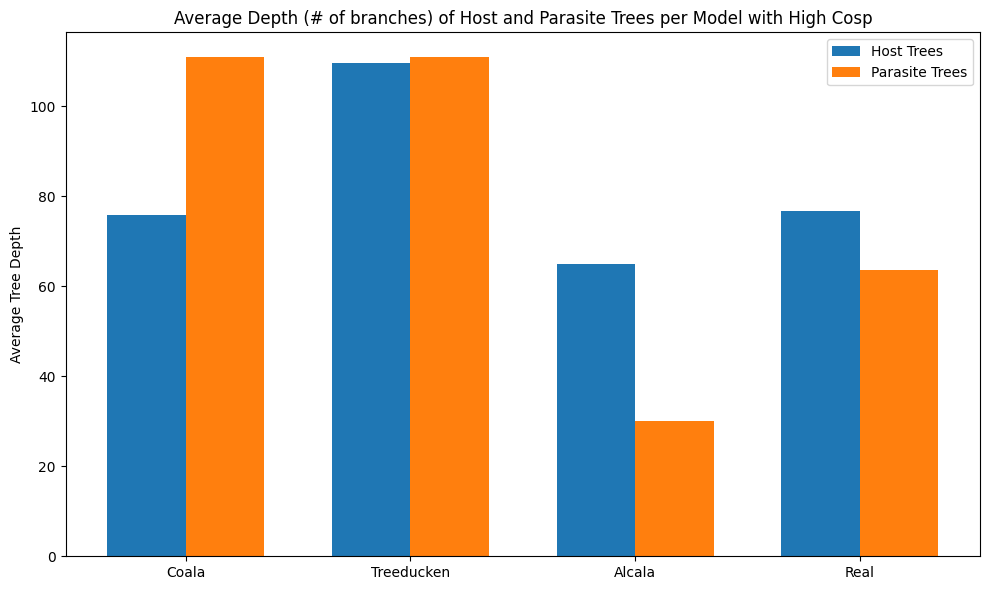

In [53]:
import matplotlib.pyplot as plt

# Compute average depths
host_depths = [
    average_host_tree_depth(datasets_coala_cosp),
    average_host_tree_depth(datasets_treeducken_cosp),
    average_host_tree_depth(datasets_alcala_cosp),
    average_host_tree_depth(real_dataset),
]

# Compute average depths
parasite_depths = [
    average_parasite_tree_depth(datasets_coala_cosp),
    average_parasite_tree_depth(datasets_treeducken_cosp),
    average_parasite_tree_depth(datasets_alcala_cosp),
    average_parasite_tree_depth(real_dataset),
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala', 'Real']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_depths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_depths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Depth')
plt.title('Average Depth (# of branches) of Host and Parasite Trees per Model with High Cosp')
plt.legend()
plt.tight_layout()
plt.show()

- Compare trees using depth and branches lengths

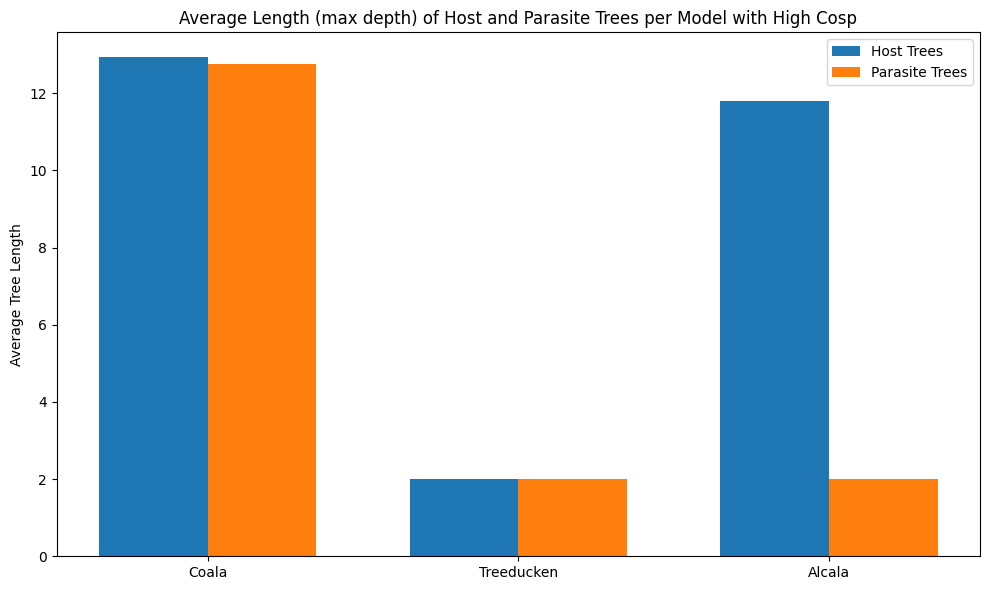

In [55]:
import matplotlib.pyplot as plt

# Compute average lengths
host_lengths = [
    average_host_tree_length(datasets_coala_cosp),
    average_host_tree_length(datasets_treeducken_cosp),
    average_host_tree_length(datasets_alcala_cosp),
    
]

# Compute average lengths
parasite_lengths = [
    average_parasite_tree_length(datasets_coala_cosp),
    average_parasite_tree_length(datasets_treeducken_cosp),
    average_parasite_tree_length(datasets_alcala_cosp)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_lengths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_lengths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Length')
plt.title('Average Length (max depth) of Host and Parasite Trees per Model with High Cosp')
plt.legend()
plt.tight_layout()
plt.show()

- Compare trees using number of leaves

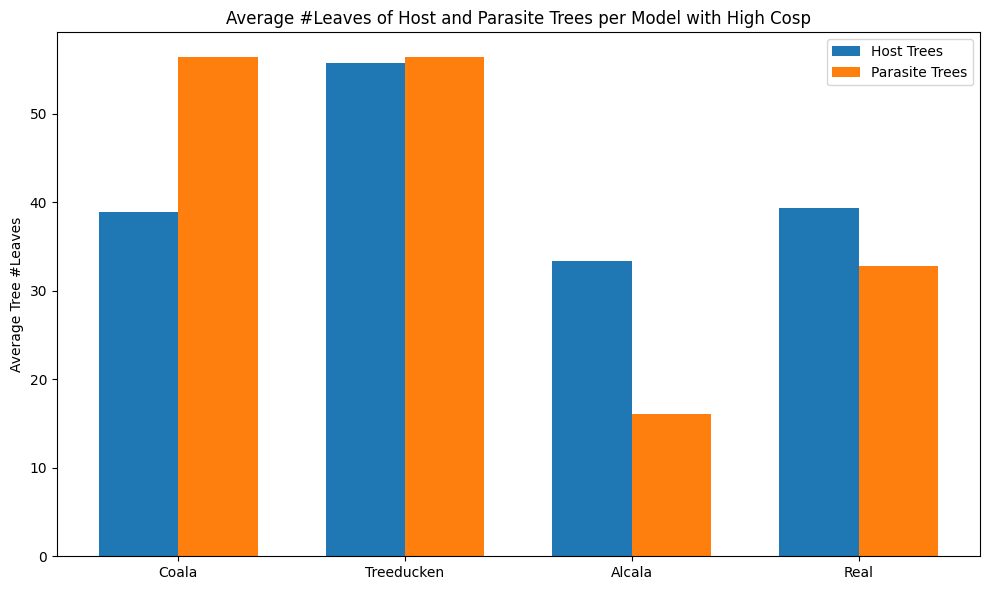

In [56]:
# Compute average depths
host_leaves = [
    average_host_tree_leaves(datasets_coala_cosp),
    average_host_tree_leaves(datasets_treeducken_cosp),
    average_host_tree_leaves(datasets_alcala_cosp),
    average_host_tree_leaves(real_dataset),
]

# Compute average depths
parasite_leaves = [
    average_parasite_tree_leaves(datasets_coala_cosp),
    average_parasite_tree_leaves(datasets_treeducken_cosp),
    average_parasite_tree_leaves(datasets_alcala_cosp), 
    average_parasite_tree_leaves(real_dataset),
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala', 'Real']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_leaves, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_leaves, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree #Leaves')
plt.title('Average #Leaves of Host and Parasite Trees per Model with High Cosp')
plt.legend()
plt.tight_layout()
plt.show()

- compare tree metrics (cherry, sacking and coless indeces)

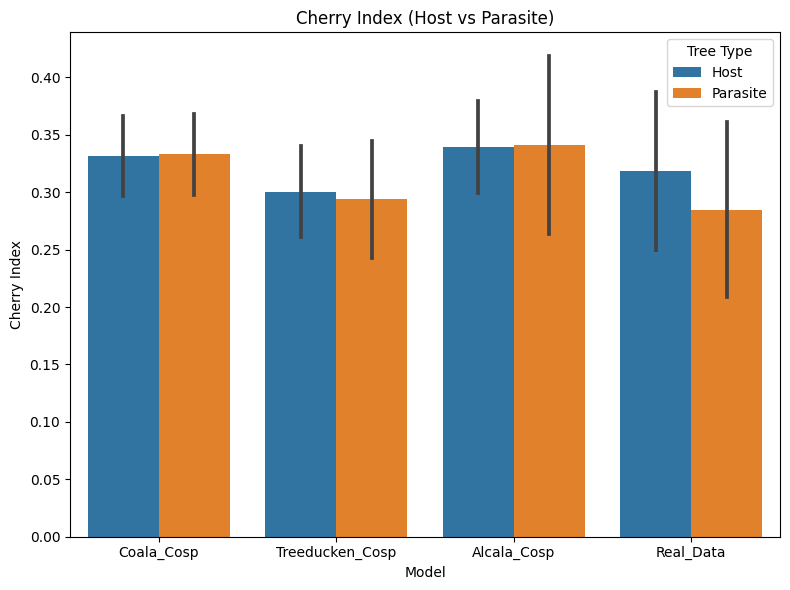

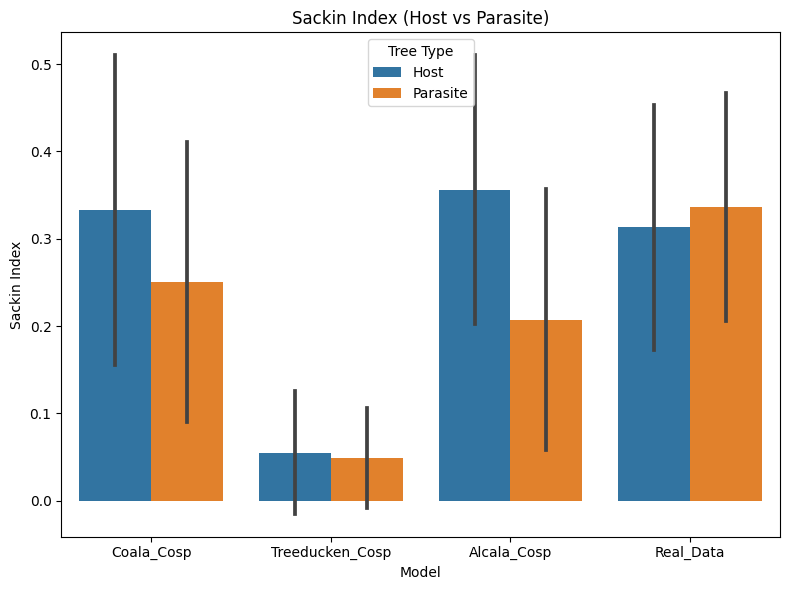

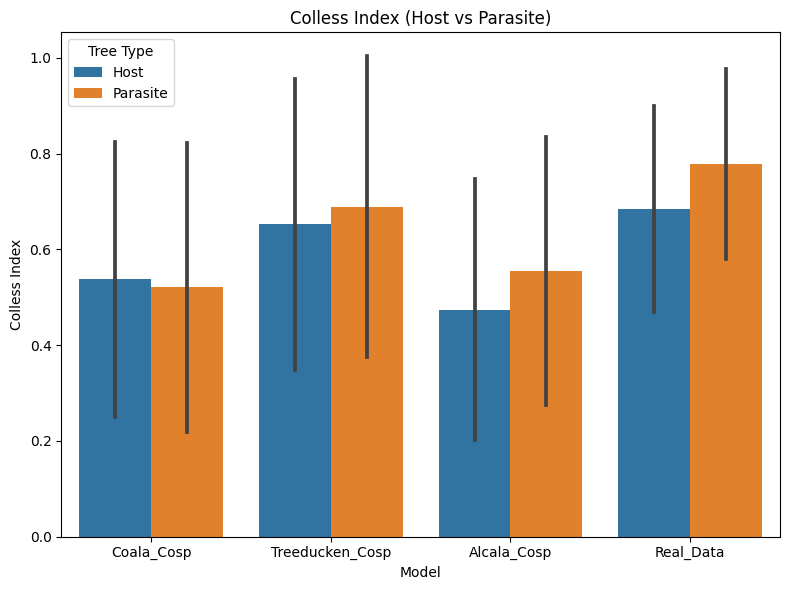

In [57]:
import openpyxl
coala_cosp_metrics = compute_tree_metrics(datasets_coala_cosp, model_name="Coala_Cosp")
treeducken_cosp_metrics = compute_tree_metrics(datasets_treeducken_cosp, model_name="Treeducken_Cosp")
alcala_cosp_metrics = compute_tree_metrics(datasets_alcala_cosp, model_name="Alcala_Cosp")
real_data_metrics = compute_tree_metrics(real_dataset, model_name="Real_Data")
comparison_metrics_cosp = pd.concat([coala_cosp_metrics, treeducken_cosp_metrics, alcala_cosp_metrics, real_data_metrics])

comparison_metrics_cosp.to_excel('comparison_metrics_cosp.xlsx', index=False)

metrics_to_plot = [
    'cherry_index_host', 'cherry_index_parasite',
    'sackin_index_host', 'sackin_index_parasite',
    'colless_index_host', 'colless_index_parasite'
]

plot_metric_comparison_paired(comparison_metrics_cosp, 'cherry_index')
plot_metric_comparison_paired(comparison_metrics_cosp, 'sackin_index')
plot_metric_comparison_paired(comparison_metrics_cosp, 'colless_index')

- parafit value

In [58]:
df_coala = run_all_parafit(datasets_coala_cosp, "Coala_Cosp", max_workers=6)
df_treeducken = run_all_parafit(datasets_treeducken_cosp, "Treeducken_Cosp", max_workers=6)
df_alcala = run_all_parafit(datasets_alcala_cosp, "Alcala_Cosp", max_workers=6)
df_real_data = run_all_parafit(real_dataset, "Real_Data", max_workers=6)

# Combine
df_all_parafit = pd.concat([df_coala, df_treeducken, df_alcala, df_real_data], ignore_index=True)
df_all_parafit['is_significant'] = df_all_parafit['parafit_pval'] < 0.05

# Summary
summary = df_all_parafit.groupby("model").agg(
    mean_stat=("parafit_stat", "mean"),
    std_stat=("parafit_stat", "std"),
    num_datasets=("parafit_stat", "count"),
    num_significant=("is_significant", "sum")
)
summary["pct_significant"] = 100 * summary["num_significant"] / summary["num_datasets"]
summary = summary.round(2)
summary.to_excel("parafit_summary_cosp.xlsx")
print(summary)

Running ParaFit for 94 datasets with 6 threads
Running ParaFit for 100 datasets with 6 threads
Running ParaFit for 100 datasets with 6 threads


Errore in `[<-`(`*tmp*`, p, h, value = 1) : subscript fuori limite
Chiamate: compute_parafit
Esecuzione interrotta


[ERROR] R script failed for Dataset_14.tgl: 
Running ParaFit for 37 datasets with 6 threads
[ERROR] R script failed for COG3715.nex: 
[ERROR] R script failed for CT.nex: 
[ERROR] R script failed for CA.nex: 


Errore in `[<-`(`*tmp*`, p, h, value = 1) : subscript fuori limite
Chiamate: compute_parafit
In aggiunta: Messaggi di avvertimento:
1: In dist.nodes(x) : the tree has no branch length: fixing them to one.
2: In dist.nodes(x) : the tree has no branch length: fixing them to one.
Esecuzione interrotta
Errore in parafit(D_host, D_parasite, assoc_matrix, nperm = nperm, test = TRUE) : 
  Host D matrix has negative eigenvalues. Rerun with correction="lingoes" or correction="cailliez"
Chiamate: compute_parafit -> parafit
In aggiunta: Messaggi di avvertimento:
1: In dist.nodes(x) : the tree has no branch length: fixing them to one.
2: In dist.nodes(x) : the tree has no branch length: fixing them to one.
Esecuzione interrotta
Errore in parafit(D_host, D_parasite, assoc_matrix, nperm = nperm, test = TRUE) : 
  Host D matrix has negative eigenvalues. Rerun with correction="lingoes" or correction="cailliez"
Chiamate: compute_parafit -> parafit
In aggiunta: Messaggi di avvertimento:
1: In dist.nodes

[ERROR] R script failed for CP.nex: 
[ERROR] R script failed for Wolbacchia.nex: 
[ERROR] R script failed for datset_ficus.nex: 
[ERROR] R script failed for COG4964.nex: 


...

Errore in parafit(D_host, D_parasite, assoc_matrix, nperm = nperm, test = TRUE) : 
  Host D matrix has negative eigenvalues. Rerun with correction="lingoes" or correction="cailliez"
Chiamate: compute_parafit -> parafit
In aggiunta: Messaggi di avvertimento:
1: In dist.nodes(x) : the tree has no branch length: fixing them to one.
2: In dist.nodes(x) : the tree has no branch length: fixing them to one.
Esecuzione interrotta
Messaggi di avvertimento:
1: In dist.nodes(x) : the tree has no branch length: fixing them to one.
2: In dist.nodes(x) : the tree has no branch length: fixing them to one.


[ERROR] R script failed for TD.nex: 


Messaggi di avvertimento:
1: In dist.nodes(x) : the tree has no branch length: fixing them to one.
2: In dist.nodes(x) : the tree has no branch length: fixing them to one.
Messaggi di avvertimento:
1: In dist.nodes(x) : the tree has no branch length: fixing them to one.
2: In dist.nodes(x) : the tree has no branch length: fixing them to one.
Messaggi di avvertimento:
1: In dist.nodes(x) : the tree has no branch length: fixing them to one.
2: In dist.nodes(x) : the tree has no branch length: fixing them to one.
Messaggi di avvertimento:
1: In dist.nodes(x) : the tree has no branch length: fixing them to one.
2: In dist.nodes(x) : the tree has no branch length: fixing them to one.
Messaggi di avvertimento:
1: In dist.nodes(x) : the tree has no branch length: fixing them to one.
2: In dist.nodes(x) : the tree has no branch length: fixing them to one.
Messaggi di avvertimento:
1: In dist.nodes(x) : the tree has no branch length: fixing them to one.
2: In dist.nodes(x) : the tree has no bra

                    mean_stat      std_stat  num_datasets  num_significant  \
model                                                                        
Alcala_Cosp      4.119810e+03  1.208001e+04            41                7   
Coala_Cosp       1.110418e+08  3.208617e+08            94               94   
Real_Data        1.580772e+04  2.168283e+04            23               13   
Treeducken_Cosp  6.627660e+03  1.273424e+04           100               88   

                 pct_significant  
model                             
Alcala_Cosp                17.07  
Coala_Cosp                100.00  
Real_Data                  56.52  
Treeducken_Cosp            88.00  


Messaggi di avvertimento:
1: In dist.nodes(x) : the tree has no branch length: fixing them to one.
2: In dist.nodes(x) : the tree has no branch length: fixing them to one.
Messaggi di avvertimento:
1: In dist.nodes(x) : the tree has no branch length: fixing them to one.
2: In dist.nodes(x) : the tree has no branch length: fixing them to one.


In [80]:
summary

,mean_stat,std_stat,num_datasets,num_significant,pct_significant
model,,,,,
Alcala_Cosp,4.119810e+03,1.208001e+04,41,7,17.07
Coala_Cosp,1.110418e+08,3.208617e+08,94,94,100.00
Real_Data,1.580772e+04,2.168283e+04,23,13,56.52
Treeducken_Cosp,6.627660e+03,1.273424e+04,100,88,88.00


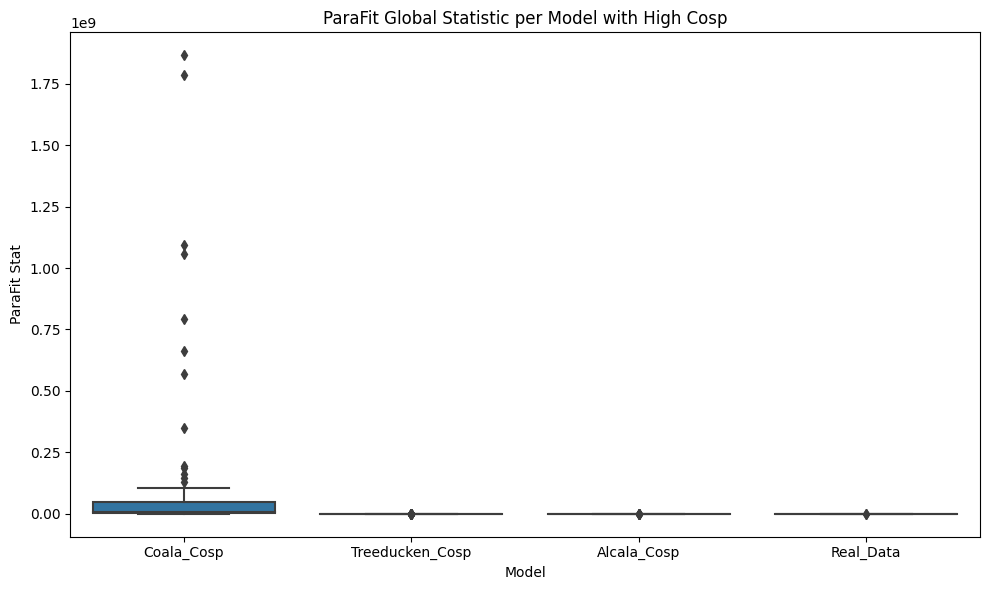

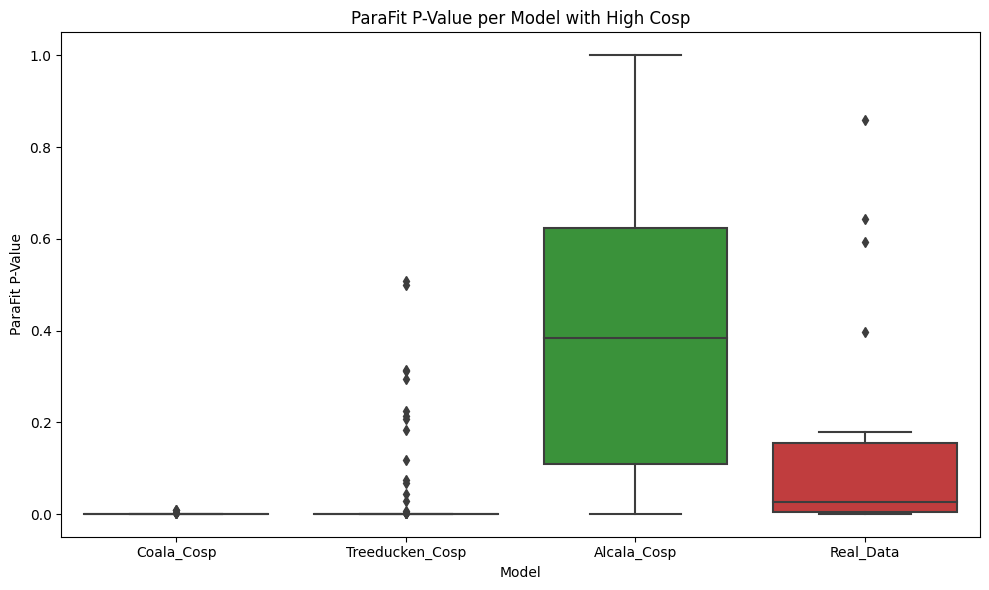

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_parafit, x="model", y="parafit_stat")
plt.title("ParaFit Global Statistic per Model with High Cosp")
plt.ylabel("ParaFit Stat")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_parafit, x="model", y="parafit_pval")
plt.title("ParaFit P-Value per Model with High Cosp")
plt.ylabel("ParaFit P-Value")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

### High Switch

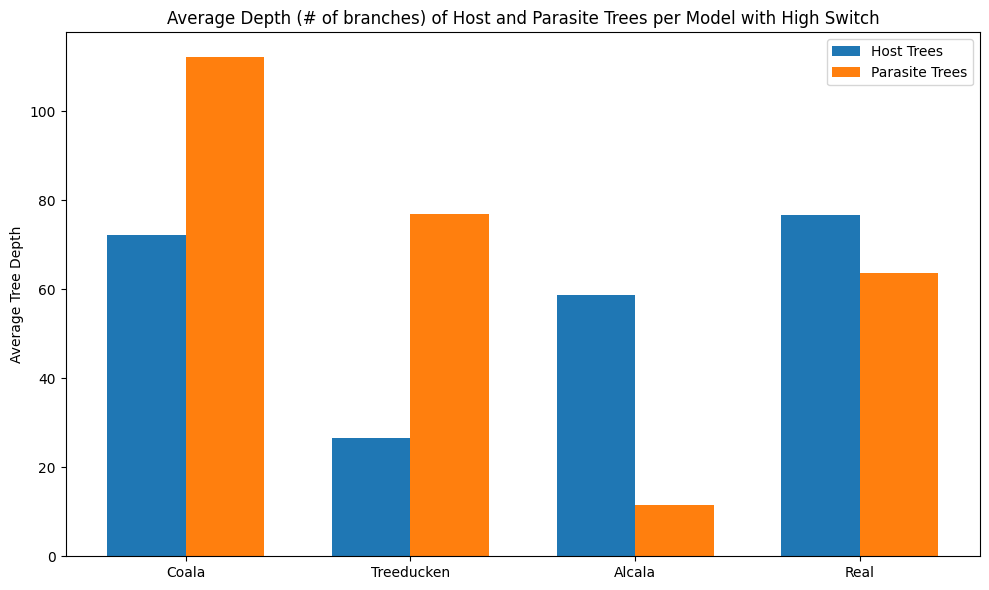

In [60]:
host_depths = [
    average_host_tree_depth(datasets_coala_switch),
    average_host_tree_depth(datasets_treeducken_switch),
    average_host_tree_depth(datasets_alcala_switch),
    average_host_tree_depth(real_dataset)
]

# Compute average depths
parasite_depths = [
    average_parasite_tree_depth(datasets_coala_switch),
    average_parasite_tree_depth(datasets_treeducken_switch),
    average_parasite_tree_depth(datasets_alcala_switch),
    average_parasite_tree_depth(real_dataset)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala', 'Real']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_depths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_depths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Depth')
plt.title('Average Depth (# of branches) of Host and Parasite Trees per Model with High Switch')
plt.legend()
plt.tight_layout()
plt.show()

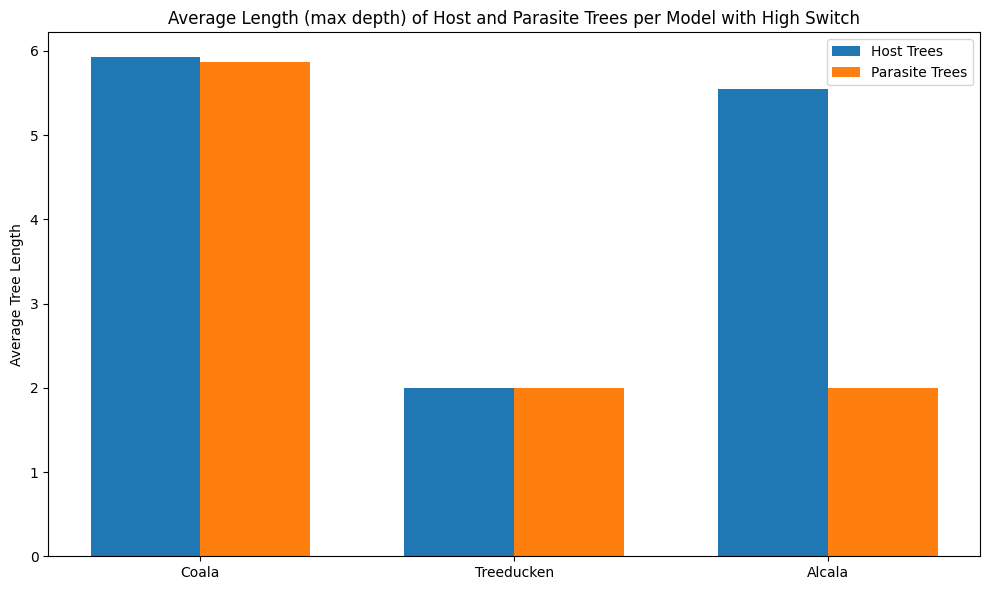

In [44]:
host_lengths = [
    average_host_tree_length(datasets_coala_switch),
    average_host_tree_length(datasets_treeducken_switch),
    average_host_tree_length(datasets_alcala_switch)
]

# Compute average lengths
parasite_lengths = [
    average_parasite_tree_length(datasets_coala_switch),
    average_parasite_tree_length(datasets_treeducken_switch),
    average_parasite_tree_length(datasets_alcala_switch)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_lengths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_lengths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Length')
plt.title('Average Length (max depth) of Host and Parasite Trees per Model with High Switch')
plt.legend()
plt.tight_layout()
plt.show()

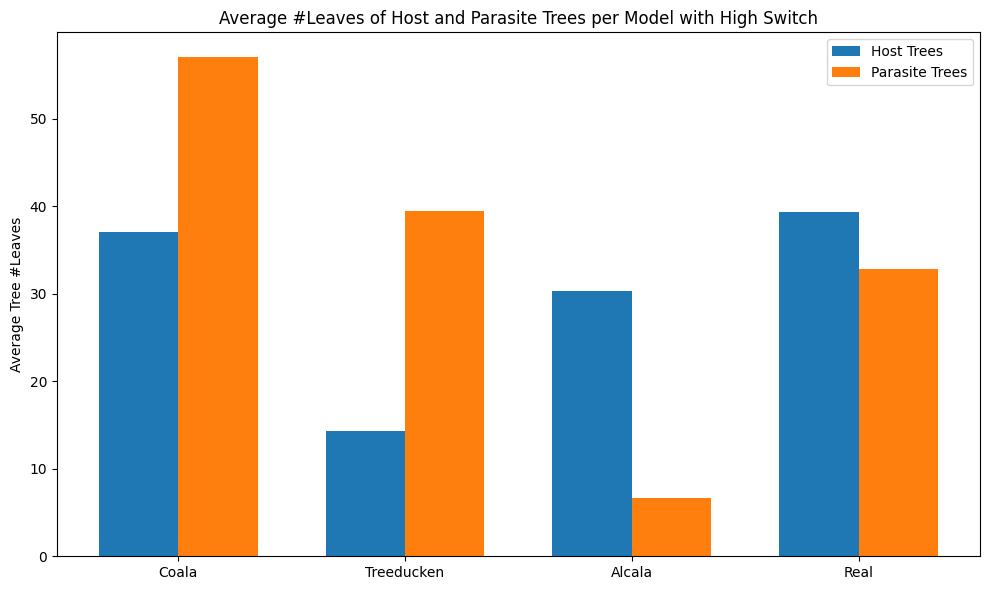

In [61]:
host_leaves = [
    average_host_tree_leaves(datasets_coala_switch),
    average_host_tree_leaves(datasets_treeducken_switch),
    average_host_tree_leaves(datasets_alcala_switch),
    average_host_tree_leaves(real_dataset)
]

# Compute average depths
parasite_leaves = [
    average_parasite_tree_leaves(datasets_coala_switch),
    average_parasite_tree_leaves(datasets_treeducken_switch),
    average_parasite_tree_leaves(datasets_alcala_switch),
    average_parasite_tree_leaves(real_dataset)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala', 'Real']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_leaves, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_leaves, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree #Leaves')
plt.title('Average #Leaves of Host and Parasite Trees per Model with High Switch')
plt.legend()
plt.tight_layout()
plt.show()

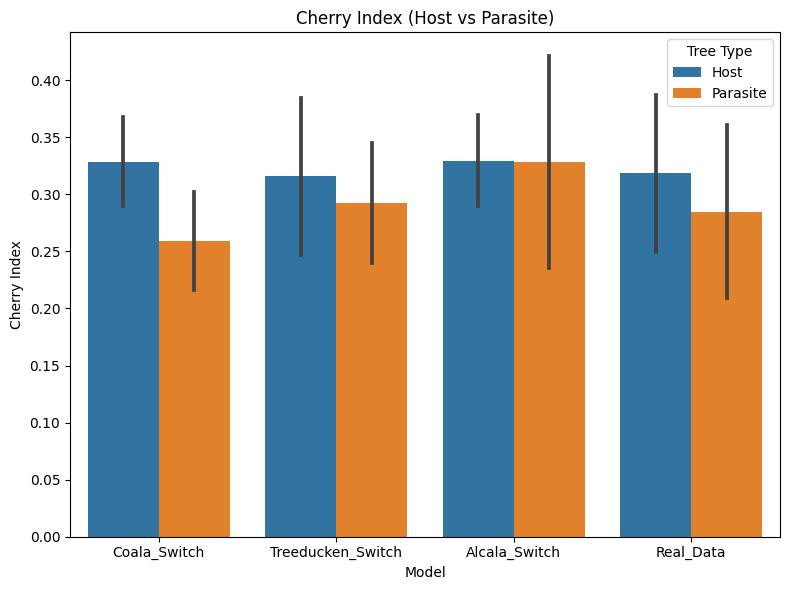

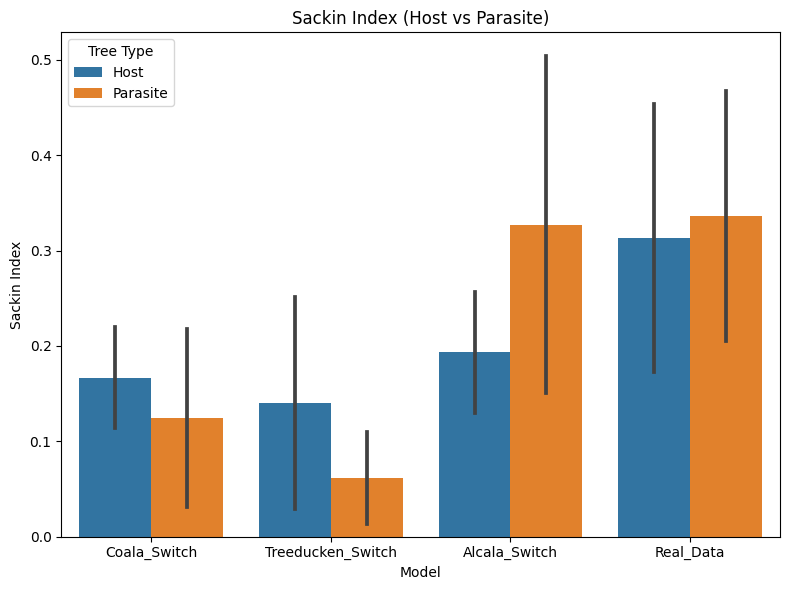

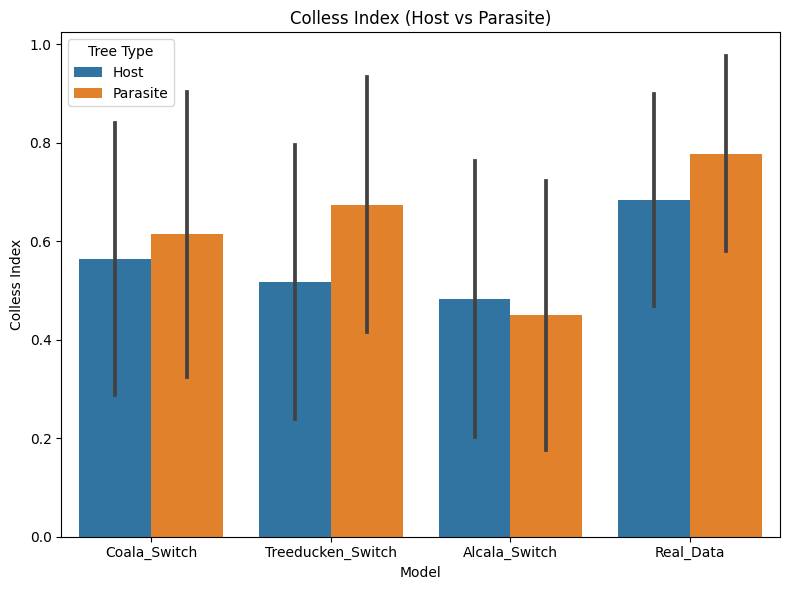

In [62]:
coala_switch_metrics = compute_tree_metrics(datasets_coala_switch, model_name="Coala_Switch")
treeducken_switch_metrics = compute_tree_metrics(datasets_treeducken_switch, model_name="Treeducken_Switch")
alcala_switch_metrics = compute_tree_metrics(datasets_alcala_switch, model_name="Alcala_Switch")
comparison_metrics_switch = pd.concat([coala_switch_metrics, treeducken_switch_metrics, alcala_switch_metrics, real_data_metrics])

comparison_metrics_switch.to_excel('comparison_metrics_switch.xlsx', index=False)
    
metrics_to_plot = [
    'cherry_index_host', 'cherry_index_parasite',
    'sackin_index_host', 'sackin_index_parasite',
    'colless_index_host', 'colless_index_parasite'
]


plot_metric_comparison_paired(comparison_metrics_switch, 'cherry_index')
plot_metric_comparison_paired(comparison_metrics_switch, 'sackin_index')
plot_metric_comparison_paired(comparison_metrics_switch, 'colless_index')

- parafit values

In [63]:
df_coala = run_all_parafit(datasets_coala_switch, "Coala_Switch",  max_workers=6)
df_treeducken = run_all_parafit(datasets_treeducken_switch, "Treeducken_Switch",  max_workers=6)
df_alcala = run_all_parafit(datasets_alcala_switch, "Alcala_Switch",  max_workers=6)

# Combine all results
df_all_parafit_switch = pd.concat([df_coala, df_treeducken, df_alcala, df_real_data], ignore_index=True)
df_all_parafit_switch['is_significant'] = df_all_parafit_switch['parafit_pval'] < 0.05
    
# Summary stats
summary_switch = df_all_parafit_switch.groupby("model").agg(
    mean_stat=("parafit_stat", "mean"),
    std_stat=("parafit_stat", "std"),
    num_datasets=("parafit_stat", "count"),
    num_significant=("is_significant", "sum")
)

# Add percentage of significant results
summary_switch["pct_significant"] = 100 * summary_switch["num_significant"] / summary_switch["num_datasets"]

# Round for readability
summary_switch = summary_switch.round(2)
summary_switch.to_excel("parafit_summary_switch.xlsx")

print(summary_switch)

Running ParaFit for 96 datasets with 6 threads
Running ParaFit for 100 datasets with 6 threads
Running ParaFit for 100 datasets with 6 threads


Errore in `[<-`(`*tmp*`, p, h, value = 1) : subscript fuori limite
Chiamate: compute_parafit
Esecuzione interrotta


[ERROR] R script failed for Dataset_65.tgl: 
                   mean_stat   std_stat  num_datasets  num_significant  \
model                                                                    
Alcala_Switch         219.66     552.73            30                1   
Coala_Switch       209176.92  263044.20            96               17   
Real_Data           15807.72   21682.83            23               13   
Treeducken_Switch    5816.92   36745.62            97               62   

                   pct_significant  
model                               
Alcala_Switch                 3.33  
Coala_Switch                 17.71  
Real_Data                    56.52  
Treeducken_Switch            63.92  


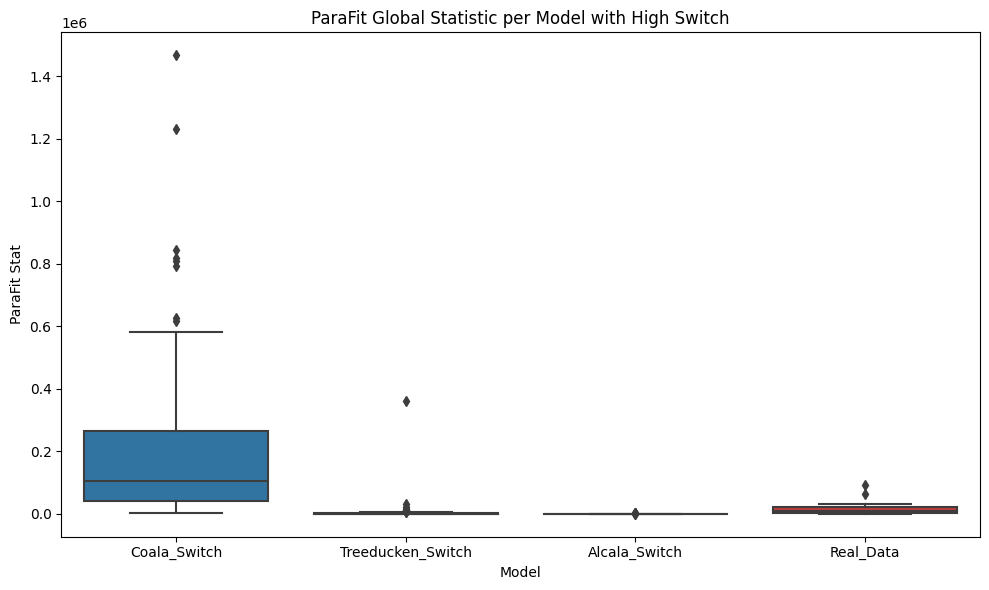

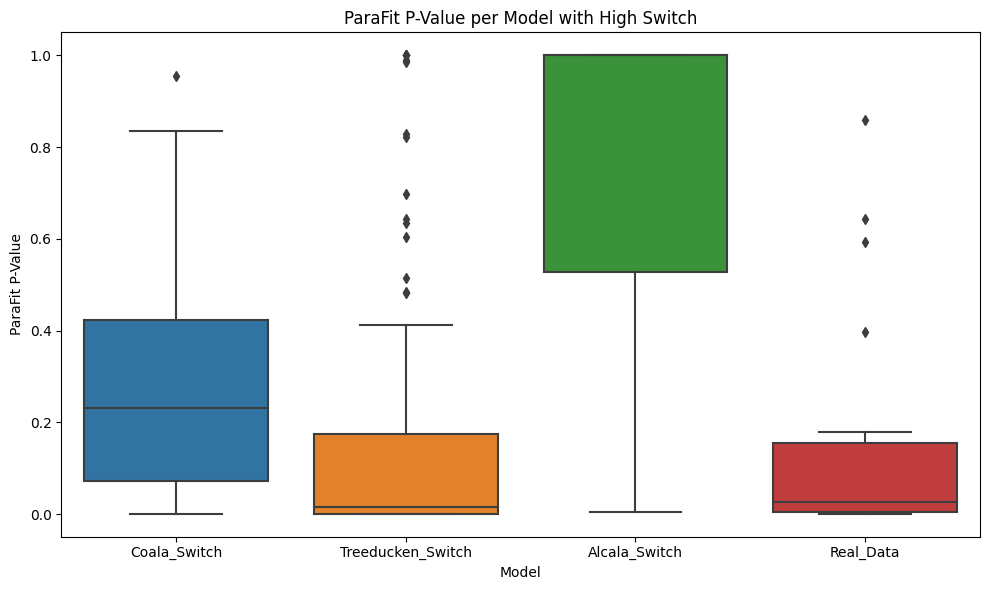

In [64]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_parafit_switch, x="model", y="parafit_stat")
plt.title("ParaFit Global Statistic per Model with High Switch")
plt.ylabel("ParaFit Stat")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_parafit_switch, x="model", y="parafit_pval")
plt.title("ParaFit P-Value per Model with High Switch")
plt.ylabel("ParaFit P-Value")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

### Medium Values

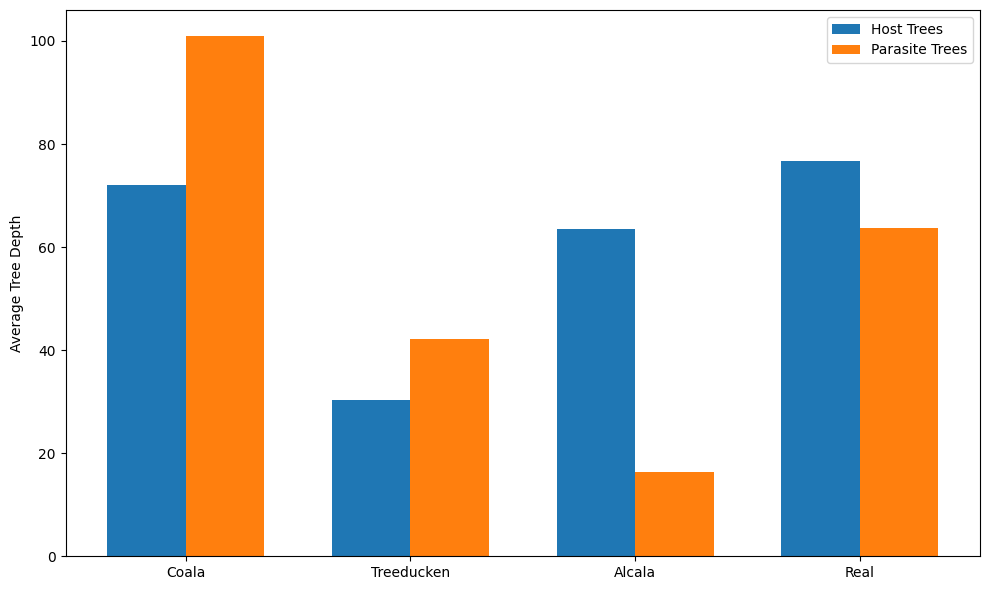

In [ ]:
host_depths = [
    average_host_tree_depth(datasets_coala_med),
    average_host_tree_depth(datasets_treeducken_medium),
    average_host_tree_depth(datasets_alcala_medium),
    average_host_tree_depth(real_dataset)
]

# Compute average depths
parasite_depths = [
    average_parasite_tree_depth(datasets_coala_med),
    average_parasite_tree_depth(datasets_treeducken_medium),
    average_parasite_tree_depth(datasets_alcala_medium),
    average_parasite_tree_depth(real_dataset)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala', 'Real']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_depths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_depths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Depth')
plt.title('Average Depth (# of branches) of Host and Parasite Trees per Model with Medium Values')
plt.legend()
plt.tight_layout()
plt.show()

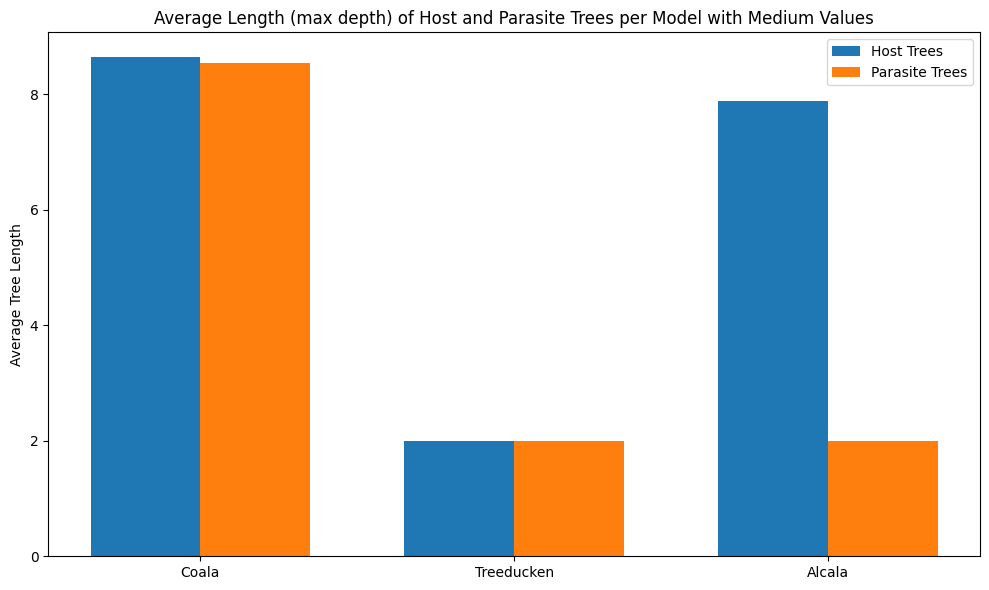

In [50]:
host_lengths = [
    average_host_tree_length(datasets_coala_med),
    average_host_tree_length(datasets_treeducken_medium),
    average_host_tree_length(datasets_alcala_medium)
]

# Compute average lengths
parasite_lengths = [
    average_parasite_tree_length(datasets_coala_med),
    average_parasite_tree_length(datasets_treeducken_medium),
    average_parasite_tree_length(datasets_alcala_medium)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_lengths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_lengths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Length')
plt.title('Average Length (max depth) of Host and Parasite Trees per Model with Medium Values')
plt.legend()
plt.tight_layout()
plt.show()

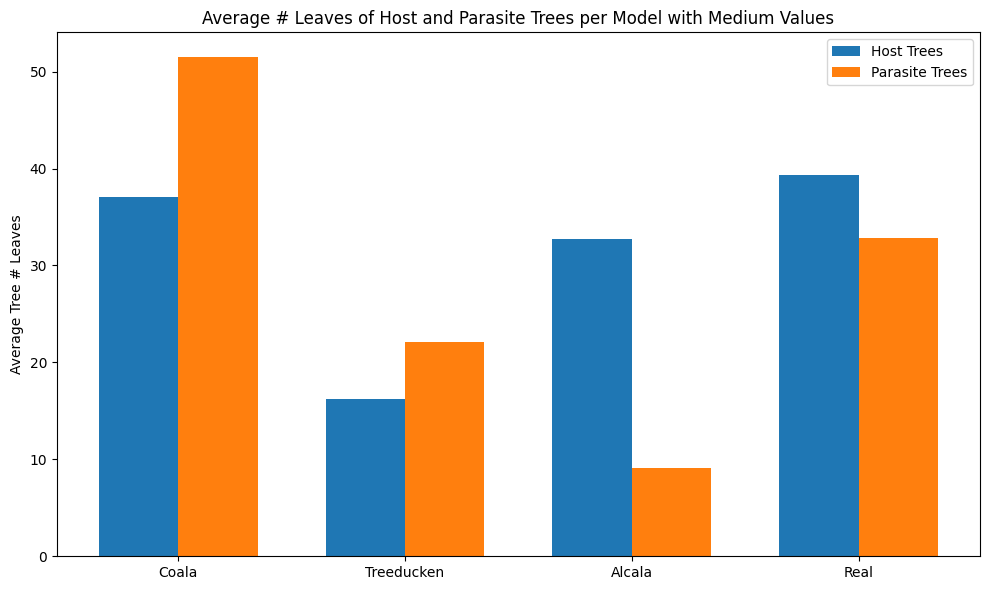

In [113]:
host_leaves = [
    average_host_tree_leaves(datasets_coala_med),
    average_host_tree_leaves(datasets_treeducken_medium),
    average_host_tree_leaves(datasets_alcala_medium),
    average_host_tree_leaves(real_dataset)
]

# Compute average lengths
parasite_leaves = [
    average_parasite_tree_leaves(datasets_coala_med),
    average_parasite_tree_leaves(datasets_treeducken_medium),
    average_parasite_tree_leaves(datasets_alcala_medium),
    average_parasite_tree_leaves(real_dataset)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala', 'Real']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_leaves, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_leaves, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree # Leaves')
plt.title('Average # Leaves of Host and Parasite Trees per Model with Medium Values')
plt.legend()
plt.tight_layout()
plt.show()

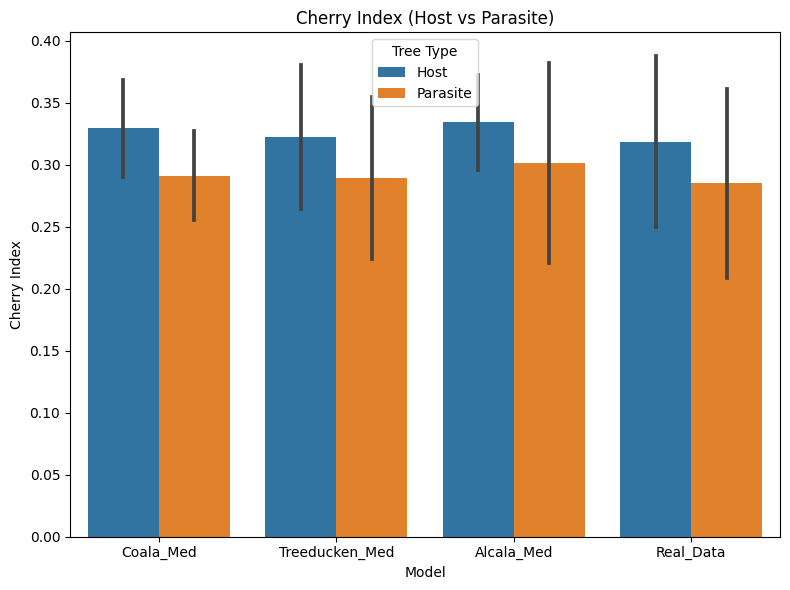

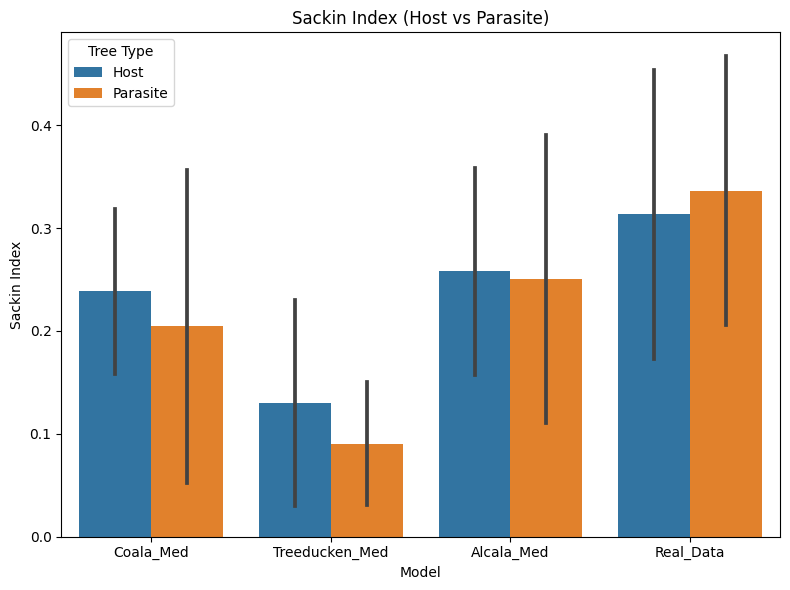

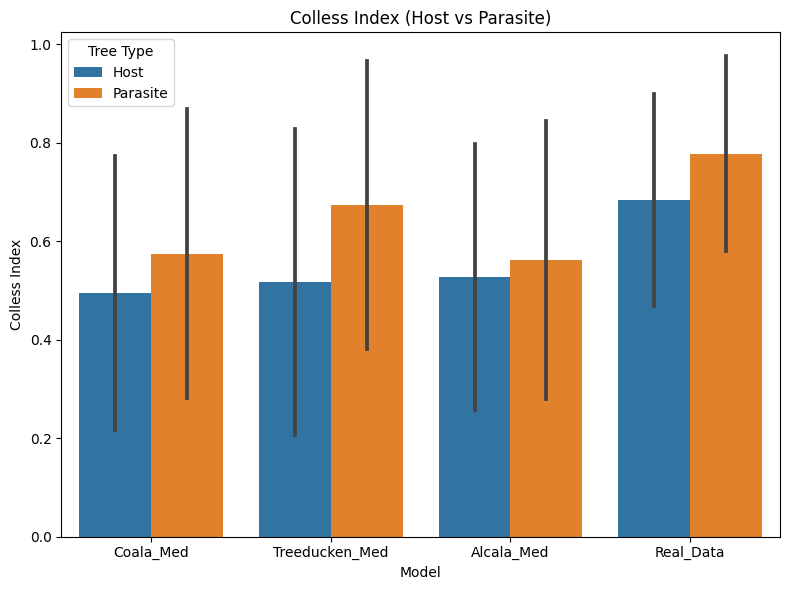

In [114]:
coala_medium_metrics = compute_tree_metrics(datasets_coala_med, model_name="Coala_Med")
treeducken_medium_metrics = compute_tree_metrics(datasets_treeducken_medium, model_name="Treeducken_Med")
alcala_medium_metrics = compute_tree_metrics(datasets_alcala_medium, model_name="Alcala_Med")
comparison_metrics_medium = pd.concat([coala_medium_metrics, treeducken_medium_metrics, alcala_medium_metrics, real_data_metrics])

comparison_metrics_medium.to_excel('comparison_metrics_medium.xlsx', index=False)

metrics_to_plot = [
    'cherry_index_host', 'cherry_index_parasite',
    'sackin_index_host', 'sackin_index_parasite',
    'colless_index_host', 'colless_index_parasite'
]



plot_metric_comparison_paired(comparison_metrics_medium, 'cherry_index')
plot_metric_comparison_paired(comparison_metrics_medium, 'sackin_index')
plot_metric_comparison_paired(comparison_metrics_medium, 'colless_index')

In [115]:
comparison_metrics_medium_real = comparison_metrics_medium[comparison_metrics_medium['model'] == 'Real_Data']
comparison_metrics_medium_real

,model,filename,host_leaves,parasite_leaves,cherry_index_host,cherry_index_parasite,sackin_index_host,sackin_index_parasite,colless_index_host,colless_index_parasite
0,Real_Data,CP.nex,6,29,0.333333,0.344828,0.500000,0.275862,0.699074,0.963004
1,Real_Data,IFL.nex,17,17,0.294118,0.294118,0.307958,0.321799,0.911295,0.679916
2,Real_Data,COG3715.nex,100,40,0.310000,0.275000,0.085900,0.235625,0.545058,0.973638
3,Real_Data,Wolbacchia.nex,387,387,0.302326,0.183463,0.034627,0.052741,0.837175,0.997296
4,Real_Data,CA.nex,41,30,0.317073,0.266667,0.191553,0.198889,0.765421,0.801111
5,Real_Data,CT.nex,19,19,0.263158,0.263158,0.329640,0.337950,0.930037,0.940181
6,Real_Data,datset_ficus.nex,204,153,0.328431,0.287582,0.068627,0.101200,0.995050,0.993376
7,Real_Data,RM.nex,5,5,0.200000,0.200000,0.560000,0.560000,0.688000,0.688000
8,Real_Data,GL.nex,8,10,0.250000,0.400000,0.468750,0.380000,0.568878,0.624000
9,Real_Data,COG4964.nex,100,27,0.310000,0.296296,0.085900,0.238683,0.545058,0.945865


- parafit value 

In [68]:
df_coala = run_all_parafit(datasets_coala_med, "Coala_Medium", max_workers=8)
df_treeducken = run_all_parafit(datasets_treeducken_medium, "Treeducken_Medium", max_workers=8)
df_alcala = run_all_parafit(datasets_alcala_medium, "Alcala_Medium", max_workers=8)

# Combine all results
df_all_parafit_medium = pd.concat([df_coala, df_treeducken, df_alcala, df_real_data], ignore_index=True)

df_all_parafit_medium['is_significant'] = df_all_parafit_medium['parafit_pval'] < 0.05

# Summary stats
summary_medium = df_all_parafit_medium.groupby("model").agg(
    mean_stat=("parafit_stat", "mean"),
    std_stat=("parafit_stat", "std"),
    num_datasets=("parafit_stat", "count"),
    num_significant=("is_significant", "sum")
)

# Add percentage of significant results
summary_medium["pct_significant"] = 100 * summary_medium["num_significant"] / summary_medium["num_datasets"]

# Round for readability
summary_medium = summary_medium.round(2)
summary_medium.to_excel("parafit_summary_medium.xlsx")

print(summary_medium)

Running ParaFit for 100 datasets with 8 threads
Running ParaFit for 100 datasets with 8 threads
Running ParaFit for 100 datasets with 8 threads


Errore in `[<-`(`*tmp*`, p, h, value = 1) : subscript fuori limite
Chiamate: compute_parafit
Esecuzione interrotta


[ERROR] R script failed for Dataset_57.tgl: 


Errore in `[<-`(`*tmp*`, p, h, value = 1) : subscript fuori limite
Chiamate: compute_parafit
Esecuzione interrotta
Errore in `[<-`(`*tmp*`, p, h, value = 1) : subscript fuori limite
Chiamate: compute_parafit
Esecuzione interrotta


[ERROR] R script failed for Dataset_15.tgl: 
[ERROR] R script failed for Dataset_14.tgl: 


Errore in data.frame(eig[1:k], rel.eig, bs, cum.eig, cum.bs) : 
  row.names contiene valori missing
Chiamate: compute_parafit -> parafit -> pcoa -> data.frame
Esecuzione interrotta


[ERROR] R script failed for Dataset_75.tgl: 
                    mean_stat    std_stat  num_datasets  num_significant  \
model                                                                      
Alcala_Medium          813.94     1956.51            35                7   
Coala_Medium       2408266.10  3998022.68           100               79   
Real_Data            15807.72    21682.83            23               13   
Treeducken_Medium      860.95     2107.51            97               61   

                   pct_significant  
model                               
Alcala_Medium                20.00  
Coala_Medium                 79.00  
Real_Data                    56.52  
Treeducken_Medium            62.89  


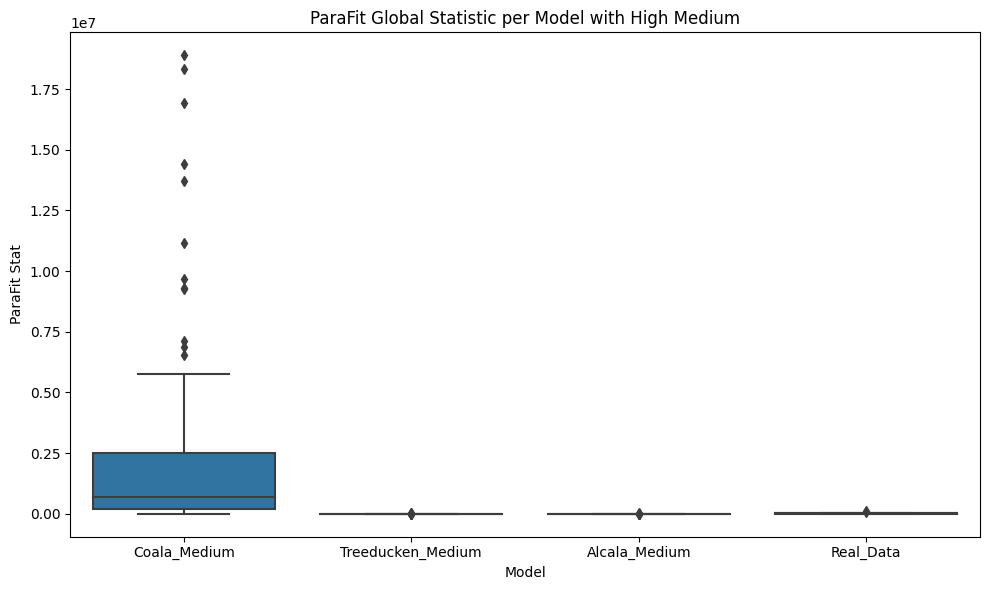

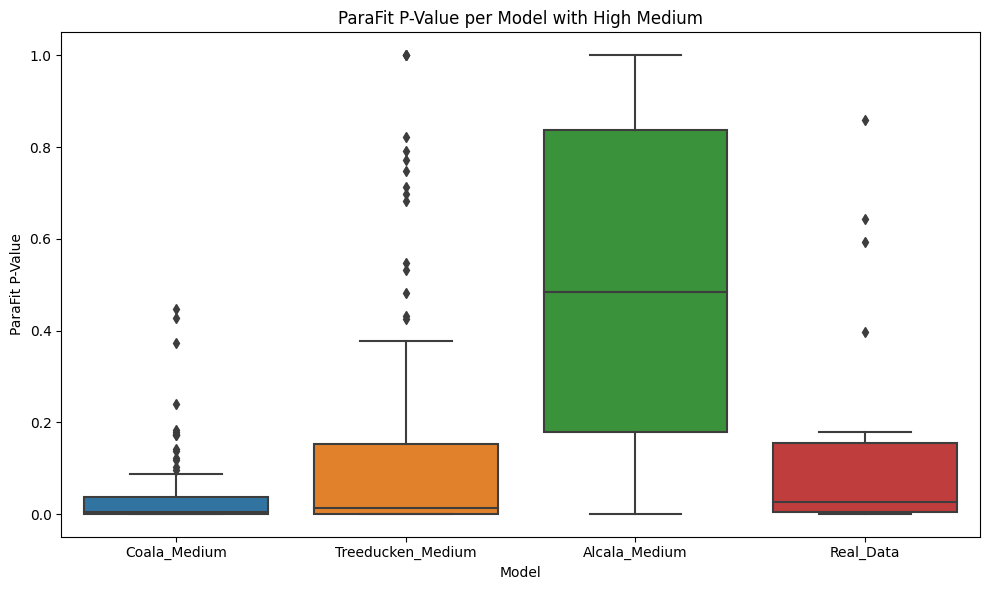

In [69]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_parafit_medium, x="model", y="parafit_stat")
plt.title("ParaFit Global Statistic per Model with High Medium")
plt.ylabel("ParaFit Stat")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_parafit_medium, x="model", y="parafit_pval")
plt.title("ParaFit P-Value per Model with High Medium")
plt.ylabel("ParaFit P-Value")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

## Compare Networks

### High Cospeciation

In [97]:
treeducken_graphs_cosp = generate_all_bipartite_graphs(datasets_treeducken_cosp, show_plots=False, save_dir="treeducken/treeducken_cosp_bipartite_graphs")
coala_graphs_cosp = generate_all_bipartite_graphs(datasets_coala_cosp, show_plots=False, save_dir="coala/coala_cosp_bipartite_graphs")
alcala_graphs_cosp = generate_all_bipartite_graphs(datasets_alcala_cosp, show_plots=False, save_dir="alcala/alcala_cosp_bipartite_graphs")
real_data_graphs = generate_all_bipartite_graphs(real_dataset, show_plots=False, save_dir="real/real_bipartite_graphs")

In [98]:
results = analyze_model_graphs(treeducken_graphs_cosp, "Treeducken") + \
          analyze_model_graphs(coala_graphs_cosp, "Coala") + \
          analyze_model_graphs(alcala_graphs_cosp, "Alcala") + \
          analyze_model_graphs(real_data_graphs, "Real")

df_graph_metrics_cosp = pd.DataFrame(results)
df_graph_metrics_cosp.to_excel("bipartite_graph_metrics_cosp.xlsx", index=False)
df_graph_metrics_cosp

/opt/anaconda3/envs/phylo/lib/python3.9/site-packages/networkx/algorithms/assortativity/correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return (xy * (M - ab)).sum() / np.sqrt(vara * varb)


,dataset,num_hosts,num_parasites,num_edges,density,avg_host_degree,avg_parasite_degree,host_hotspots,degree_assortativity,top_central_nodes,num_components
0,Treeducken_Dataset38.tgl,29,27,32,0.040868,1.103448,1.185185,3,0.000000,"[(H43, 0.03636363636363636), (H27, 0.036363636...",24
1,Treeducken_Dataset10.tgl,8,9,10,0.138889,1.250000,1.111111,2,-0.428571,"[(H14, 0.125), (H3, 0.125), (P23, 0.125), (H18...",7
2,Treeducken_Dataset11.tgl,43,59,61,0.024044,1.418605,1.033898,3,-0.244898,"[(H67, 0.04950495049504951), (H66, 0.039603960...",41
3,Treeducken_Dataset39.tgl,7,11,11,0.142857,1.571429,1.000000,2,-0.375000,"[(H14, 0.1764705882352941), (H15, 0.1764705882...",7
4,Treeducken_Dataset13.tgl,24,27,29,0.044753,1.208333,1.074074,5,-0.318182,"[(H35, 0.04), (H13, 0.04), (H39, 0.04), (H47, ...",22
...,...,...,...,...,...,...,...,...,...,...,...
326,Real_MF.nex,6,9,9,0.166667,1.500000,1.000000,1,-0.285714,"[(g,, 0.2857142857142857), (h,, 0.071428571428...",6
327,Real_AS.nex,15,16,16,0.066667,1.066667,1.000000,1,-0.066667,"[(Grace_Warbler,, 0.06666666666666667), (Y_hea...",15
328,Real_MP.nex,7,8,8,0.142857,1.142857,1.000000,1,-0.142857,"[(rubra,, 0.14285714285714285), (rubra, 0.0714...",7
329,Real_AW.nex,12,12,12,0.083333,1.000000,1.000000,0,NaN,"[(coi_coleoptera_tahiti_sc02824,, 0.0434782608...",12


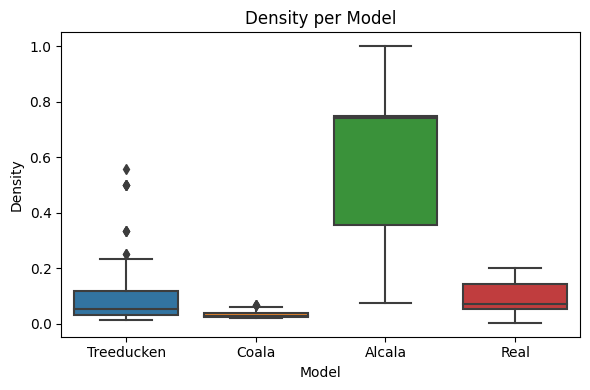

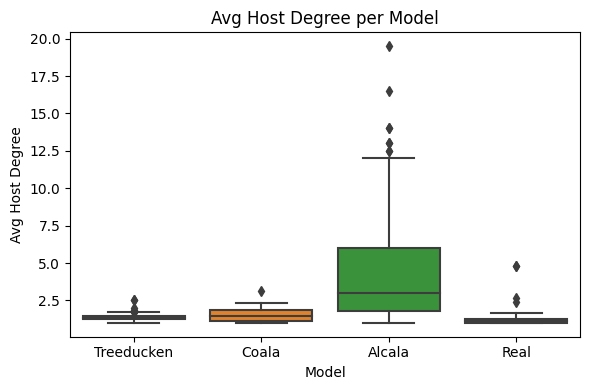

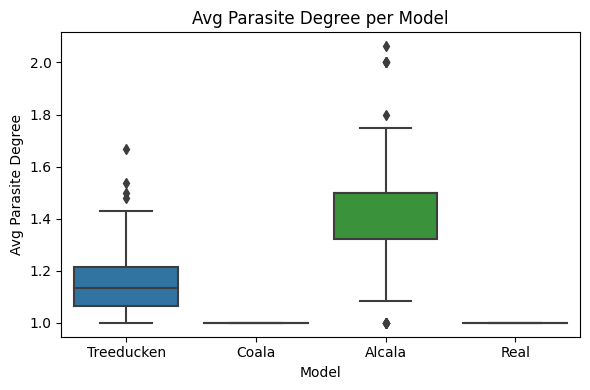

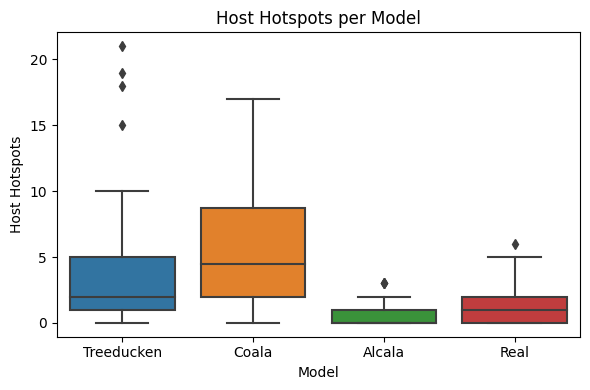

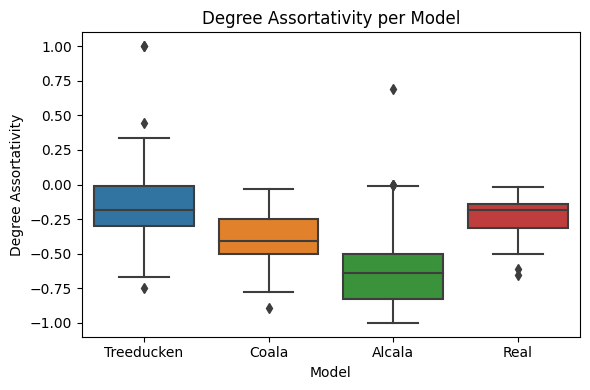

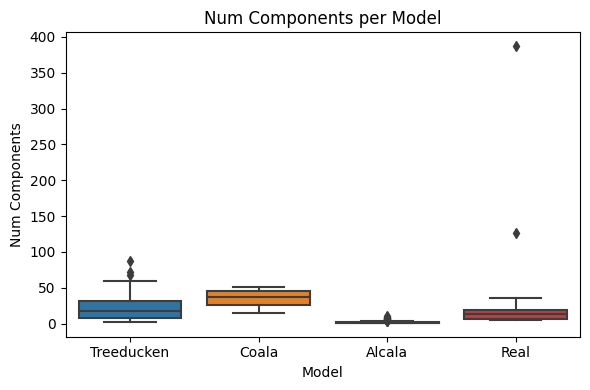

In [99]:
df_graph_metrics_cosp["model"] = df_graph_metrics_cosp["dataset"].apply(lambda x: x.split("_")[0])

metrics_to_plot = [
    "density", 
    "avg_host_degree", 
    "avg_parasite_degree", 
    "host_hotspots", 
    "degree_assortativity", 
    "num_components"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_graph_metrics_cosp, x="model", y=metric)
    plt.title(f"{metric.replace('_', ' ').title()} per Model")
    plt.ylabel(metric.replace('_', ' ').title())
    plt.xlabel("Model")
    plt.tight_layout()
    plt.show()

### High Switch

In [100]:
treeducken_graphs_switch = generate_all_bipartite_graphs(datasets_treeducken_switch, show_plots=False, save_dir="treeducken/treeducken_switch_bipartite_graphs")
coala_graphs_switch = generate_all_bipartite_graphs(datasets_coala_switch, show_plots=False, save_dir="coala/coala_switch_bipartite_graphs")
alcala_graphs_switch = generate_all_bipartite_graphs(datasets_alcala_switch, show_plots=False, save_dir="alcala/alcala_switch_bipartite_graphs")

In [101]:
results = analyze_model_graphs(treeducken_graphs_switch, "Treeducken") + \
          analyze_model_graphs(coala_graphs_switch, "Coala") + \
          analyze_model_graphs(alcala_graphs_switch, "Alcala") + \
          analyze_model_graphs(real_data_graphs, "Real")

df_graph_metrics_switch = pd.DataFrame(results)
df_graph_metrics_switch.to_excel("bipartite_graph_metrics_switch.xlsx", index=False)
df_graph_metrics_switch

/opt/anaconda3/envs/phylo/lib/python3.9/site-packages/networkx/algorithms/assortativity/correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return (xy * (M - ab)).sum() / np.sqrt(vara * varb)


,dataset,num_hosts,num_parasites,num_edges,density,avg_host_degree,avg_parasite_degree,host_hotspots,degree_assortativity,top_central_nodes,num_components
0,Treeducken_Dataset38.tgl,9,33,77,0.259259,8.555556,2.333333,1,-0.689082,"[(H10, 0.3902439024390244), (H1, 0.31707317073...",1
1,Treeducken_Dataset10.tgl,3,11,11,0.333333,3.666667,1.000000,1,-0.692308,"[(H9, 0.6923076923076923), (H6, 0.076923076923...",3
2,Treeducken_Dataset11.tgl,3,3,4,0.444444,1.333333,1.333333,1,-1.000000,"[(H2, 0.4), (P8, 0.4), (H8, 0.2), (H9, 0.2), (...",2
3,Treeducken_Dataset39.tgl,13,23,43,0.143813,3.307692,1.869565,3,-0.252710,"[(H16, 0.2571428571428571), (H11, 0.1714285714...",5
4,Treeducken_Dataset13.tgl,2,7,7,0.500000,3.500000,1.000000,0,-0.728916,"[(H1, 0.625), (H2, 0.25), (P6, 0.125), (P2, 0....",2
...,...,...,...,...,...,...,...,...,...,...,...
328,Real_MF.nex,6,9,9,0.166667,1.500000,1.000000,1,-0.285714,"[(g,, 0.2857142857142857), (h,, 0.071428571428...",6
329,Real_AS.nex,15,16,16,0.066667,1.066667,1.000000,1,-0.066667,"[(Grace_Warbler,, 0.06666666666666667), (Y_hea...",15
330,Real_MP.nex,7,8,8,0.142857,1.142857,1.000000,1,-0.142857,"[(rubra,, 0.14285714285714285), (rubra, 0.0714...",7
331,Real_AW.nex,12,12,12,0.083333,1.000000,1.000000,0,NaN,"[(coi_coleoptera_tahiti_sc02824,, 0.0434782608...",12


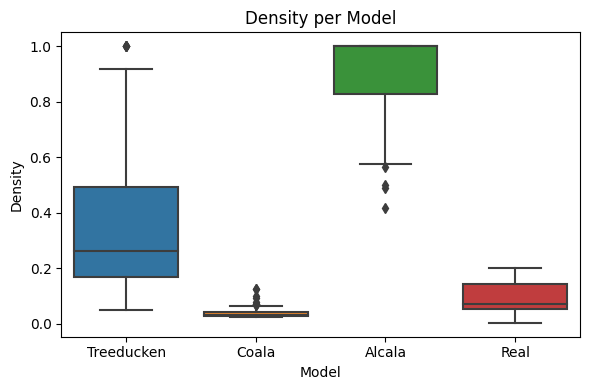

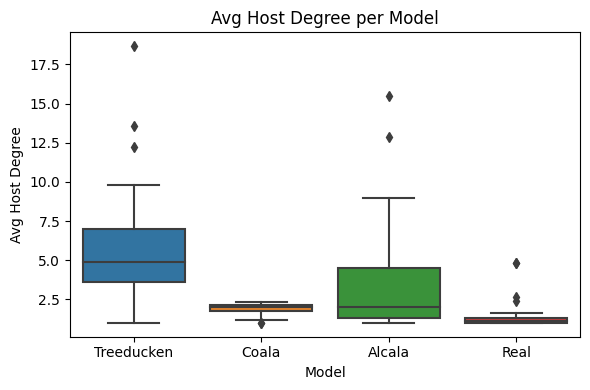

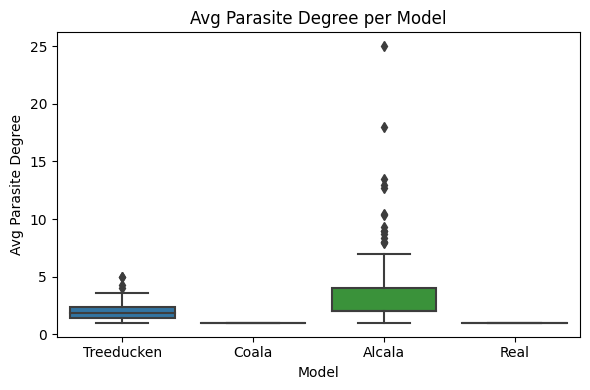

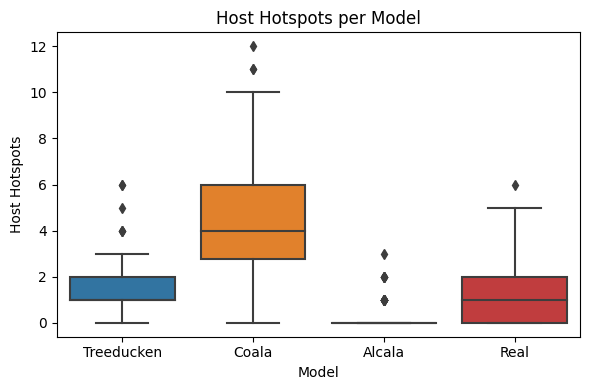

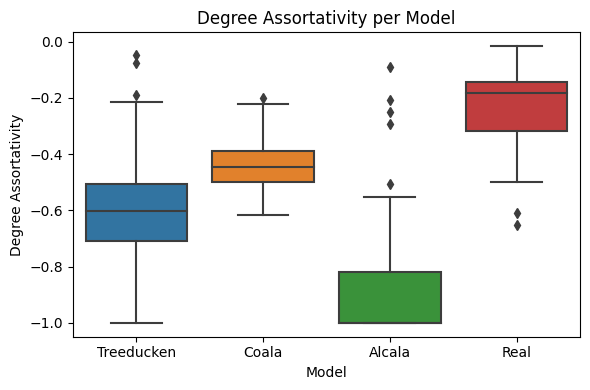

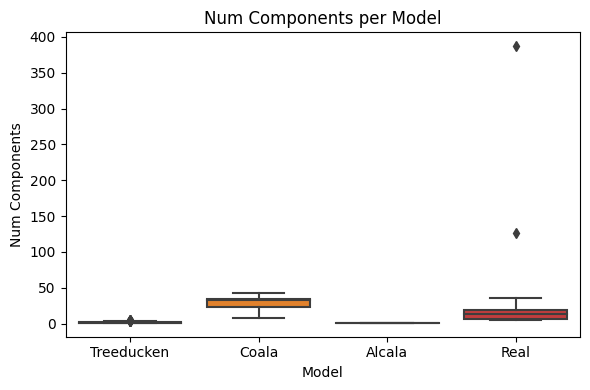

In [102]:
df_graph_metrics_switch["model"] = df_graph_metrics_switch["dataset"].apply(lambda x: x.split("_")[0])

metrics_to_plot = [
    "density", 
    "avg_host_degree", 
    "avg_parasite_degree", 
    "host_hotspots", 
    "degree_assortativity", 
    "num_components"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_graph_metrics_switch, x="model", y=metric)
    plt.title(f"{metric.replace('_', ' ').title()} per Model")
    plt.ylabel(metric.replace('_', ' ').title())
    plt.xlabel("Model")
    plt.tight_layout()
    plt.show()

### Medium values

In [103]:
treeducken_graphs_medium = generate_all_bipartite_graphs(datasets_treeducken_medium, show_plots=False, save_dir="treeducken/treeducken_medium_bipartite_graphs")
coala_graphs_medium = generate_all_bipartite_graphs(datasets_coala_med, show_plots=False, save_dir="coala/coala_medium_bipartite_graphs")
alcala_graphs_medium = generate_all_bipartite_graphs(datasets_alcala_medium, show_plots=False, save_dir="alcala/alcala_medium_bipartite_graphs")

In [104]:
results = analyze_model_graphs(treeducken_graphs_medium, "Treeducken") + \
          analyze_model_graphs(coala_graphs_medium, "Coala") + \
          analyze_model_graphs(alcala_graphs_medium, "Alcala") + \
          analyze_model_graphs(real_data_graphs, "Real")

df_graph_metrics_medium = pd.DataFrame(results)
df_graph_metrics_medium.to_excel("bipartite_graph_metrics_medium.xlsx", index=False)
df_graph_metrics_medium

/opt/anaconda3/envs/phylo/lib/python3.9/site-packages/networkx/algorithms/assortativity/correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return (xy * (M - ab)).sum() / np.sqrt(vara * varb)


,dataset,num_hosts,num_parasites,num_edges,density,avg_host_degree,avg_parasite_degree,host_hotspots,degree_assortativity,top_central_nodes,num_components
0,Treeducken_Dataset38.tgl,3,3,4,0.444444,1.333333,1.333333,1,-1.000000,"[(H2, 0.4), (P2, 0.4), (H4, 0.2), (H5, 0.2), (...",2
1,Treeducken_Dataset10.tgl,8,18,21,0.145833,2.625000,1.166667,1,-0.487252,"[(H1, 0.24), (H7, 0.16), (H5, 0.16), (H10, 0.0...",5
2,Treeducken_Dataset11.tgl,3,5,7,0.466667,2.333333,1.400000,1,-0.586667,"[(H2, 0.7142857142857142), (P4, 0.285714285714...",1
3,Treeducken_Dataset39.tgl,10,10,18,0.180000,1.800000,1.800000,3,-0.681818,"[(H13, 0.21052631578947367), (P8, 0.2105263157...",3
4,Treeducken_Dataset13.tgl,4,8,9,0.281250,2.250000,1.125000,1,-0.440000,"[(H10, 0.36363636363636365), (H7, 0.2727272727...",3
...,...,...,...,...,...,...,...,...,...,...,...
332,Real_MF.nex,6,9,9,0.166667,1.500000,1.000000,1,-0.285714,"[(g,, 0.2857142857142857), (h,, 0.071428571428...",6
333,Real_AS.nex,15,16,16,0.066667,1.066667,1.000000,1,-0.066667,"[(Grace_Warbler,, 0.06666666666666667), (Y_hea...",15
334,Real_MP.nex,7,8,8,0.142857,1.142857,1.000000,1,-0.142857,"[(rubra,, 0.14285714285714285), (rubra, 0.0714...",7
335,Real_AW.nex,12,12,12,0.083333,1.000000,1.000000,0,NaN,"[(coi_coleoptera_tahiti_sc02824,, 0.0434782608...",12


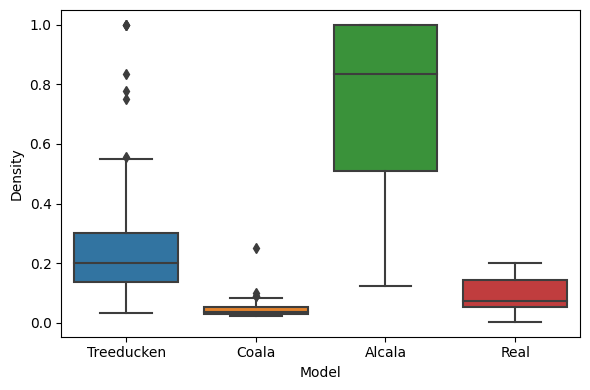

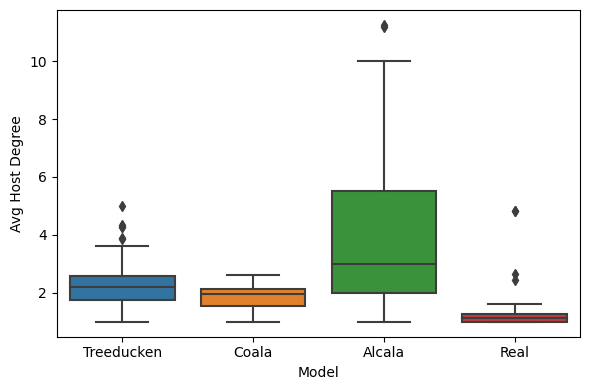

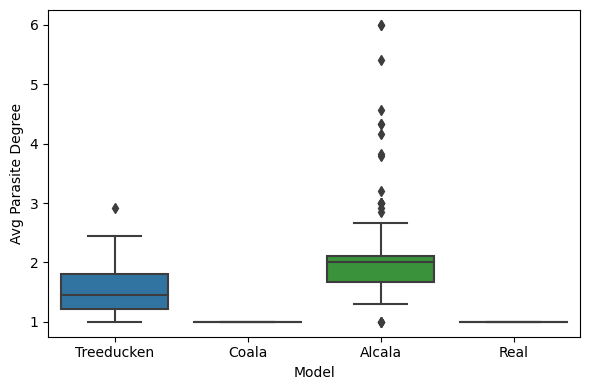

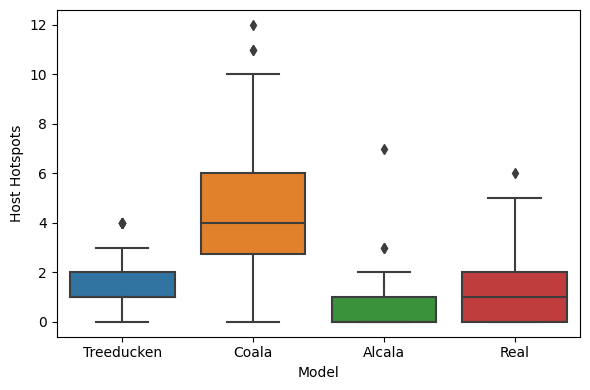

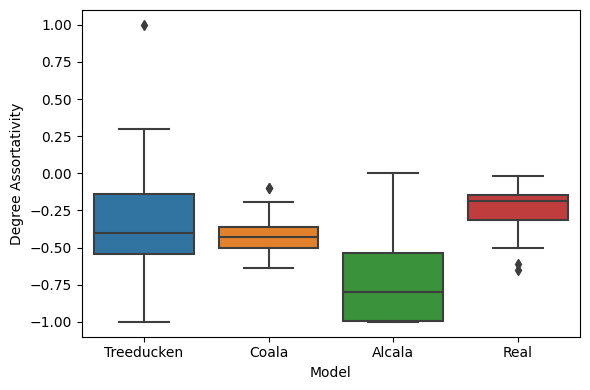

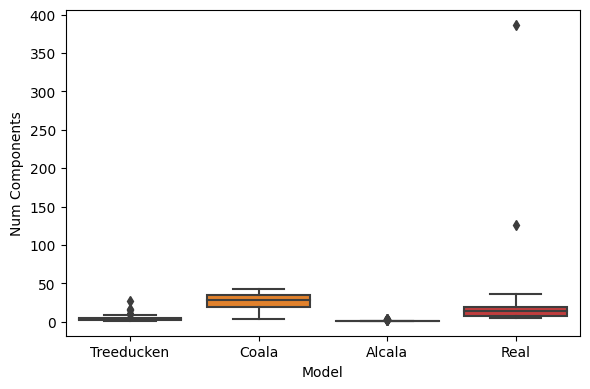

In [106]:
df_graph_metrics_medium["model"] = df_graph_metrics_medium["dataset"].apply(lambda x: x.split("_")[0])

metrics_to_plot = [
    "density", 
    "avg_host_degree", 
    "avg_parasite_degree", 
    "host_hotspots", 
    "degree_assortativity", 
    "num_components"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_graph_metrics_medium, x="model", y=metric)
    plt.ylabel(metric.replace('_', ' ').title())
    plt.xlabel("Model")
    plt.tight_layout()
    plt.show()